In [37]:
import pandas as pd

df = pd.read_csv('data/paccar_ana_shot_made.csv')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34097 entries, 0 to 34096
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   COMPANY_NAME           34097 non-null  object 
 1   PLANT_NAME             32467 non-null  object 
 2   EQUIPMENT_CODE         32467 non-null  object 
 3   COUNTER_CODE           34097 non-null  object 
 4   SHOT_START_TIME        34097 non-null  int64  
 5   SHOT_END_TIME          34097 non-null  int64  
 6   CYCLE_TIME_LIMIT1      32467 non-null  float64
 7   CYCLE_TIME_LIMIT1UNIT  32467 non-null  object 
 8   CYCLE_TIME_LIMIT2      32467 non-null  float64
 9   CYCLE_TIME_LIMIT2UNIT  32467 non-null  object 
 10  L1_ABOVE_ADJUSTED      32467 non-null  float64
 11  L2_ABOVE_ADJUSTED      32467 non-null  float64
 12  L1_BELOW_ADJUSTED      32467 non-null  float64
 13  L2_BELOW_ADJUSTED      32467 non-null  float64
 14  CONTRACTED_CYCLE_TIME  32467 non-null  float64
 15  AV

In [39]:
df.describe()

,SHOT_START_TIME,SHOT_END_TIME,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT2,L1_ABOVE_ADJUSTED,L2_ABOVE_ADJUSTED,L1_BELOW_ADJUSTED,L2_BELOW_ADJUSTED,CONTRACTED_CYCLE_TIME,AVG_VALID_CT,...,VALID_SHOT_COUNT,PRODUCTION_TIME,TOTAL_SESSION_TIME,IDLE_TIME,UPTIME_PERCENTAGE,DAY,MONTH,QUARTER,YEAR,WEEK
count,3.409700e+04,3.409700e+04,32467.0,32467.0,32467.000000,32467.000000,32467.000000,32467.000000,32467.000000,34097.000000,...,34097.000000,34097.000000,34097.000000,34097.000000,34097.000000,3.409700e+04,34097.000000,34097.000000,34097.000000,34097.000000
mean,1.720467e+18,1.720584e+18,2.0,5.0,61.061236,62.857154,58.666677,56.870759,59.863957,66.469859,...,57.323665,1615.330029,2625.507405,1010.177376,60.685175,2.023963e+07,202396.125612,20241.835968,2023.879374,202421.913130
std,1.253540e+16,1.192955e+16,0.0,0.0,89.105960,91.726724,85.611609,82.990845,87.358784,94.167488,...,84.122596,1143.824339,1145.425732,958.459651,27.536252,3.430058e+03,34.303507,3.496569,0.344344,35.537474
min,1.587818e+18,1.587818e+18,2.0,5.0,3.876000,3.990000,3.724000,3.610000,3.800000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,2.020042e+07,202004.000000,20202.000000,2020.000000,202017.000000
25%,1.715176e+18,1.715194e+18,2.0,5.0,17.340000,17.850000,16.660000,16.150000,17.000000,19.000000,...,14.000000,672.000000,1809.000000,277.000000,46.590000,2.024051e+07,202405.000000,20242.000000,2024.000000,202419.000000
50%,1.724274e+18,1.724284e+18,2.0,5.0,22.993714,23.670000,22.092000,21.415714,22.542857,27.590000,...,41.000000,1455.000000,3185.000000,786.000000,62.010000,2.024082e+07,202408.000000,20243.000000,2024.000000,202434.000000
75%,1.729686e+18,1.729691e+18,2.0,5.0,71.595859,73.701620,68.788178,66.682418,70.192019,77.000000,...,63.000000,2461.000000,3589.000000,1399.000000,79.160000,2.024102e+07,202410.000000,20244.000000,2024.000000,202443.000000
max,1.734482e+18,1.734485e+18,2.0,5.0,357.000000,367.500000,343.000000,332.500000,350.000000,998.000000,...,1000.000000,5337.000000,8043.000000,4908.000000,100.000000,2.024122e+07,202412.000000,20244.000000,2024.000000,202451.000000


In [40]:
df.isnull().sum()

COMPANY_NAME                 0
PLANT_NAME                1630
EQUIPMENT_CODE            1630
COUNTER_CODE                 0
SHOT_START_TIME              0
SHOT_END_TIME                0
CYCLE_TIME_LIMIT1         1630
CYCLE_TIME_LIMIT1UNIT     1630
CYCLE_TIME_LIMIT2         1630
CYCLE_TIME_LIMIT2UNIT     1630
L1_ABOVE_ADJUSTED         1630
L2_ABOVE_ADJUSTED         1630
L1_BELOW_ADJUSTED         1630
L2_BELOW_ADJUSTED         1630
CONTRACTED_CYCLE_TIME     1630
AVG_VALID_CT                 0
SHOT_COUNT                   0
ABOVE_COUNT                  0
WITHIN_COUNT                 0
BELOW_COUNT                  0
ABOVE_AVG_CT             13519
WITHIN_AVG_CT            19058
BELOW_AVG_CT             19696
SHOTS_MADE                   0
VALID_SHOT_COUNT             0
PRODUCTION_TIME              0
TOTAL_SESSION_TIME           0
START_TIME                   0
END_TIME                     0
IDLE_TIME                    0
UPTIME_PERCENTAGE            0
DAY                          0
MONTH   

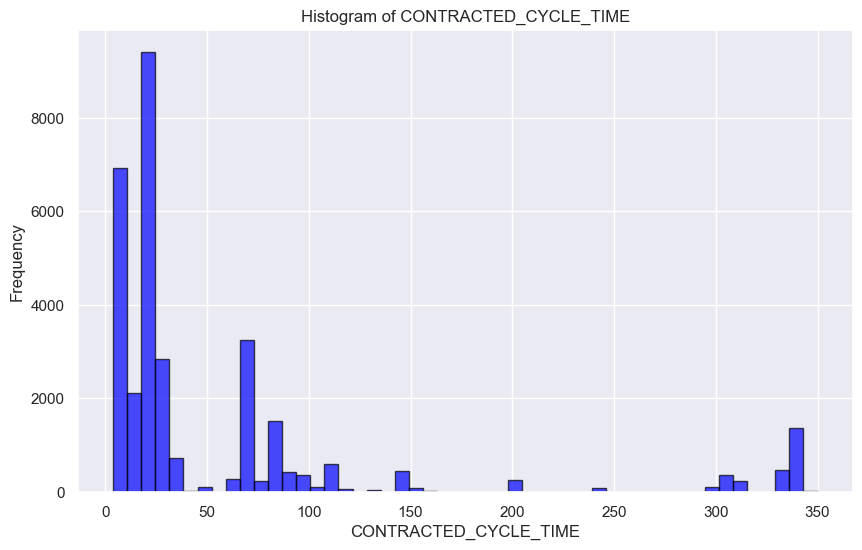

In [41]:
import matplotlib.pyplot as plt  

df['CONTRACTED_CYCLE_TIME'].hist(bins=50, color='blue', edgecolor='black', alpha=0.7,figsize=(10,6))
plt.title('Histogram of CONTRACTED_CYCLE_TIME')
plt.xlabel('CONTRACTED_CYCLE_TIME')
plt.ylabel('Frequency')
plt.show()   

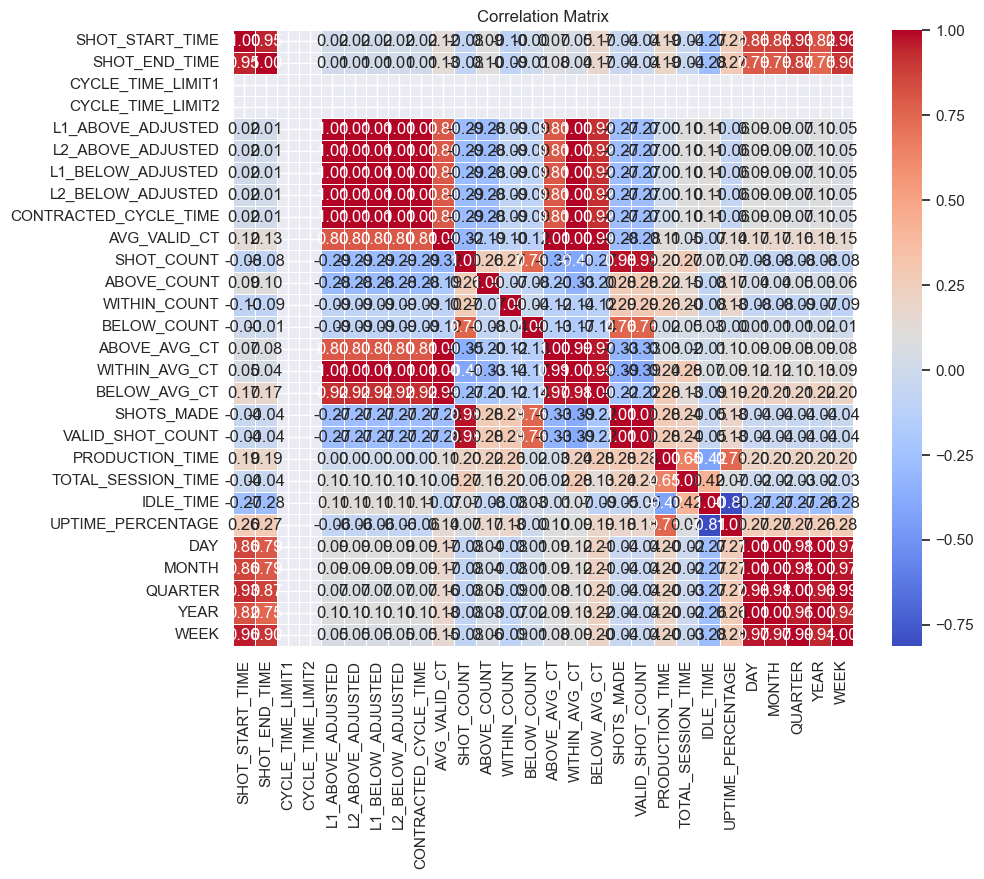

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()


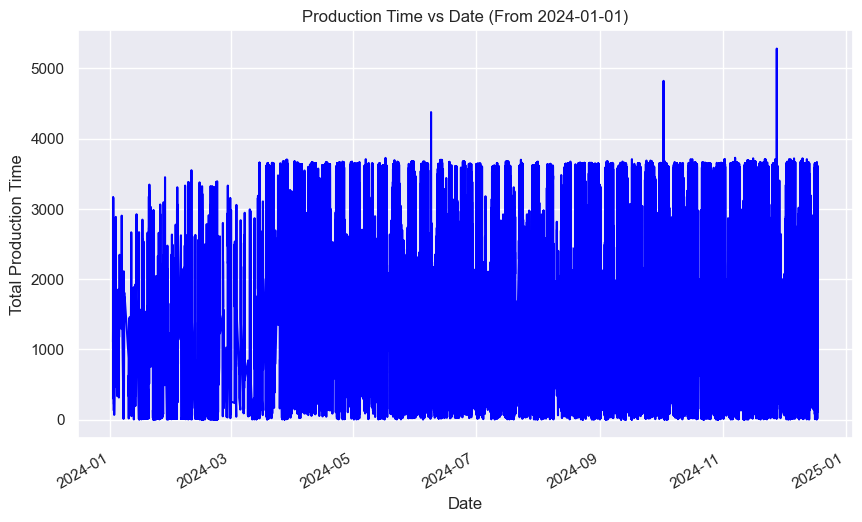

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert START_TIME and END_TIME to datetime
df['START_TIME'] = pd.to_datetime(df['START_TIME'])
df['END_TIME'] = pd.to_datetime(df['END_TIME'])

# Filter data from January 1, 2023
filtered_df = df[df['START_TIME'] >= '2024-01-01']

# Plot production time with the filtered data
filtered_df.set_index('START_TIME')['PRODUCTION_TIME'].plot(figsize=(10, 6), color='blue')
plt.title('Production Time vs Date (From 2024-01-01)')
plt.xlabel('Date')
plt.ylabel('Total Production Time')
plt.show()


In [44]:
from sklearn.cluster import KMeans

X = df[['CONTRACTED_CYCLE_TIME','SHOT_COUNT', 'PRODUCTION_TIME']].dropna()


kmeans = KMeans(n_clusters=3, random_state=0).fit(X)

df['Cluster'] = kmeans.labels_  

plt.figure(figsize=(10,6))  
sns.scatterplot(x='CONTRACTED_CYCLE_TIME', y='PRODUCTION_TIME', data=df, hue='Cluster', palette='viridis')
plt.title('K-means Clustering')
plt.show()

ValueError: Length of values (32467) does not match length of index (34097)

In [45]:
from sklearn.model_selection import train_test_split    
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X = df[['CONTRACTED_CYCLE_TIME','SHOT_COUNT', 'PRODUCTION_TIME']].dropna()
Y = df['UPTIME_PERCENTAGE'].dropna()   

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, Y_train) 

y_pred = model.predict(X_test)  
mae = mean_squared_error(Y_test, y_pred)

print('Mean Absolute Error:', mae) 

ValueError: Found input variables with inconsistent numbers of samples: [32467, 34097]

In [46]:
# Summarize key features
summary_stats = df[['CYCLE_TIME_LIMIT1', 'CYCLE_TIME_LIMIT2', 'PRODUCTION_TIME', 'UPTIME_PERCENTAGE']].describe()
print(summary_stats)

       CYCLE_TIME_LIMIT1  CYCLE_TIME_LIMIT2  PRODUCTION_TIME  \
count            32467.0            32467.0     34097.000000   
mean                 2.0                5.0      1615.330029   
std                  0.0                0.0      1143.824339   
min                  2.0                5.0         0.000000   
25%                  2.0                5.0       672.000000   
50%                  2.0                5.0      1455.000000   
75%                  2.0                5.0      2461.000000   
max                  2.0                5.0      5337.000000   

       UPTIME_PERCENTAGE  
count       34097.000000  
mean           60.685175  
std            27.536252  
min             0.000000  
25%            46.590000  
50%            62.010000  
75%            79.160000  
max           100.000000  


In [47]:
categorical_cols = ['COMPANY_NAME', 'PLANT_NAME', 'EQUIPMENT_CODE','COUNTER_CODE']
unique_counts = {col:df[col].nunique() for col in categorical_cols}
print(unique_counts)    


{'COMPANY_NAME': 9, 'PLANT_NAME': 9, 'EQUIPMENT_CODE': 175, 'COUNTER_CODE': 205}


In [48]:
import pandas as pd


# Summarize key numerical columns
key_columns = ['CYCLE_TIME_LIMIT1', 'CYCLE_TIME_LIMIT2', 'PRODUCTION_TIME', 'UPTIME_PERCENTAGE']
summary_stats = df[key_columns].describe()

print("Summary Statistics for Key Numerical Columns:")
display(summary_stats)

# Check for missing values in all columns
missing_values = df.isnull().sum()
print("\nMissing Values in Each Column:")
display(missing_values)

# Unique counts for important categorical columns
categorical_cols = ['COMPANY_NAME', 'PLANT_NAME', 'EQUIPMENT_CODE']
unique_counts = {col: df[col].nunique() for col in categorical_cols}
print("\nUnique Counts in Categorical Columns:")
display(unique_counts)


Summary Statistics for Key Numerical Columns:


,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT2,PRODUCTION_TIME,UPTIME_PERCENTAGE
count,32467.0,32467.0,34097.000000,34097.000000
mean,2.0,5.0,1615.330029,60.685175
std,0.0,0.0,1143.824339,27.536252
min,2.0,5.0,0.000000,0.000000
25%,2.0,5.0,672.000000,46.590000
50%,2.0,5.0,1455.000000,62.010000
75%,2.0,5.0,2461.000000,79.160000
max,2.0,5.0,5337.000000,100.000000



Missing Values in Each Column:


COMPANY_NAME                 0
PLANT_NAME                1630
EQUIPMENT_CODE            1630
COUNTER_CODE                 0
SHOT_START_TIME              0
SHOT_END_TIME                0
CYCLE_TIME_LIMIT1         1630
CYCLE_TIME_LIMIT1UNIT     1630
CYCLE_TIME_LIMIT2         1630
CYCLE_TIME_LIMIT2UNIT     1630
L1_ABOVE_ADJUSTED         1630
L2_ABOVE_ADJUSTED         1630
L1_BELOW_ADJUSTED         1630
L2_BELOW_ADJUSTED         1630
CONTRACTED_CYCLE_TIME     1630
AVG_VALID_CT                 0
SHOT_COUNT                   0
ABOVE_COUNT                  0
WITHIN_COUNT                 0
BELOW_COUNT                  0
ABOVE_AVG_CT             13519
WITHIN_AVG_CT            19058
BELOW_AVG_CT             19696
SHOTS_MADE                   0
VALID_SHOT_COUNT             0
PRODUCTION_TIME              0
TOTAL_SESSION_TIME           0
START_TIME                   0
END_TIME                     0
IDLE_TIME                    0
UPTIME_PERCENTAGE            0
DAY                          0
MONTH   


Unique Counts in Categorical Columns:


{'COMPANY_NAME': 9, 'PLANT_NAME': 9, 'EQUIPMENT_CODE': 175}

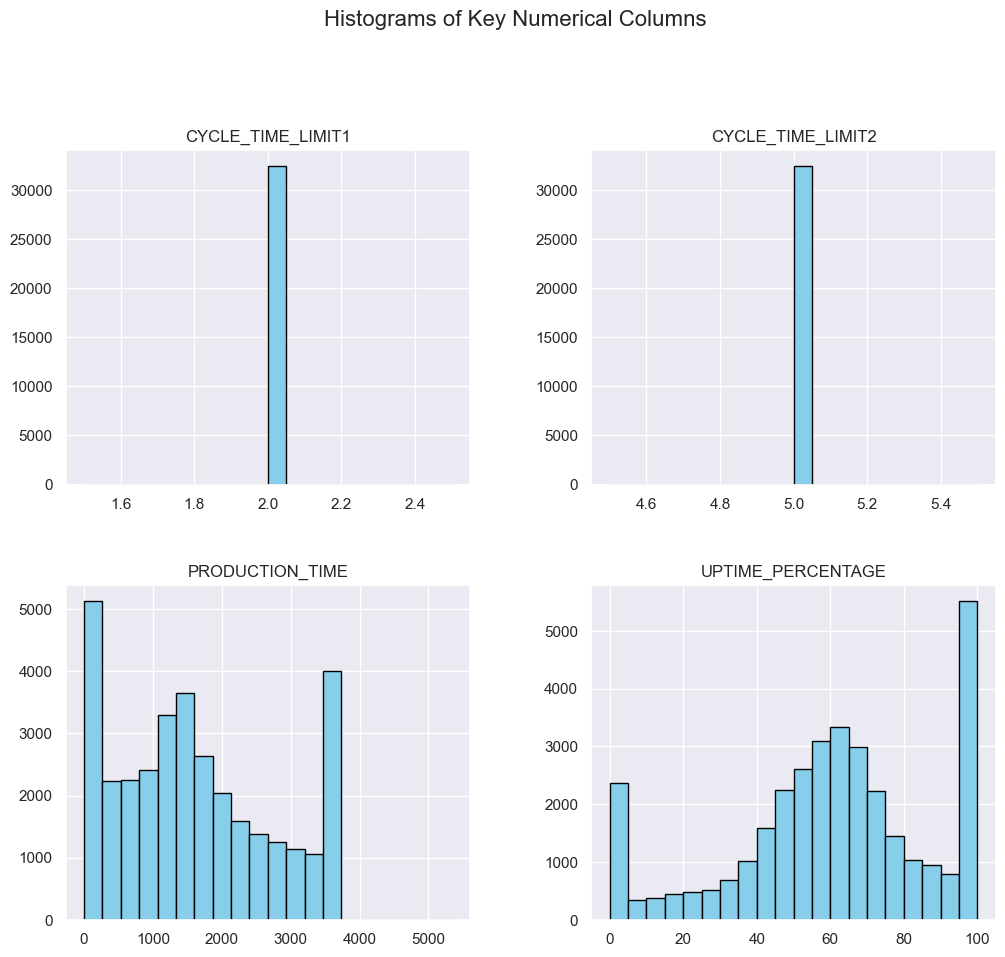

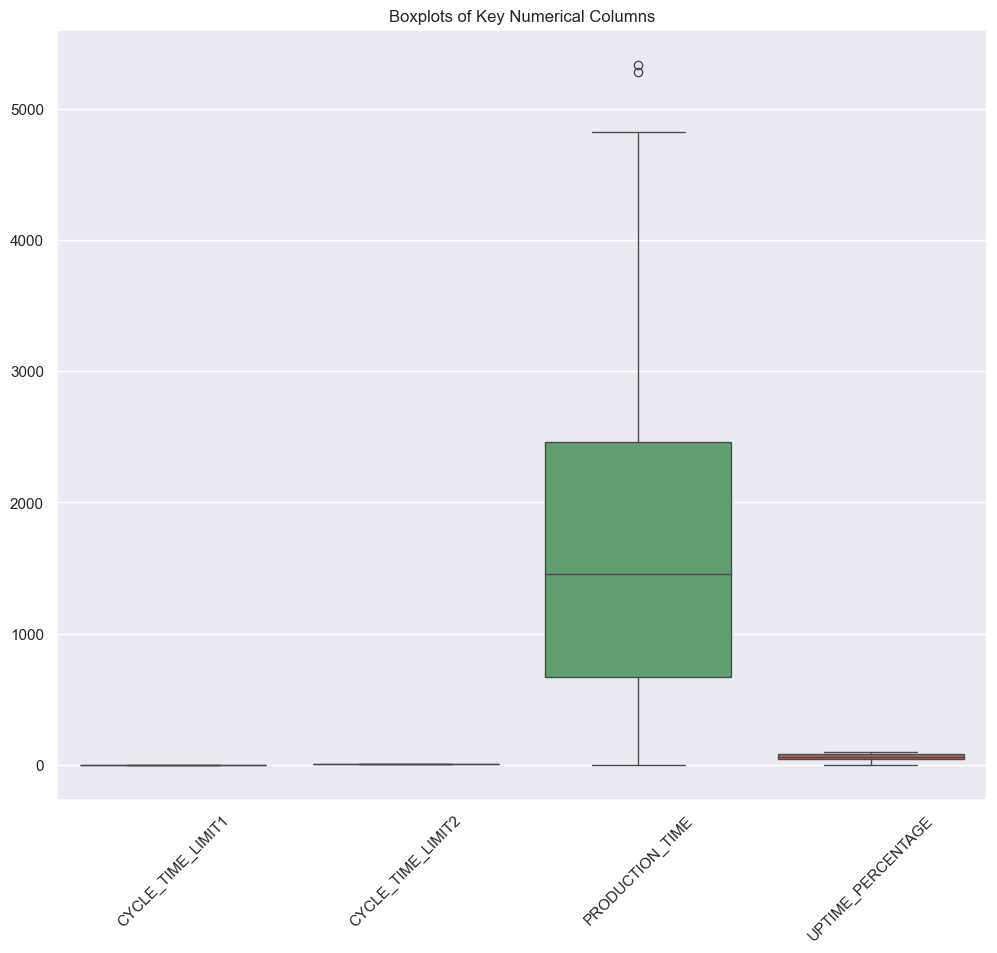

/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_47266/3412461471.py:22: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='CYCLE_TIME_LIMIT1', y='PRODUCTION_TIME', data=df, palette='viridis')


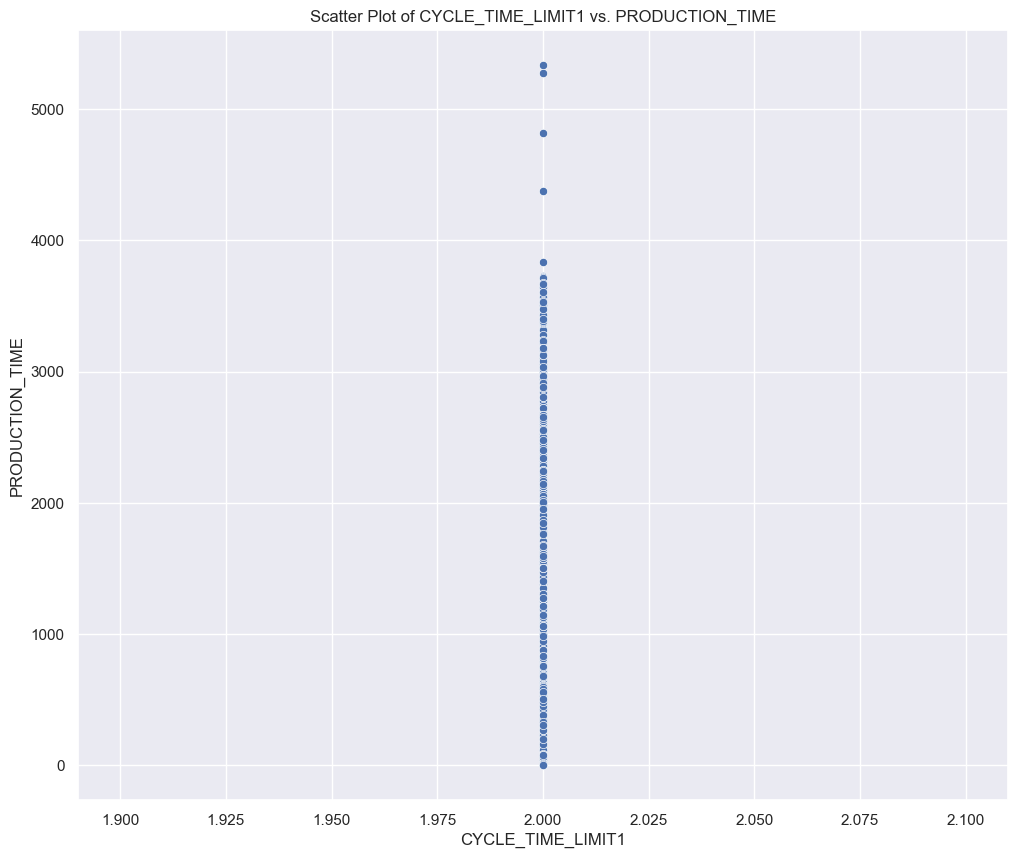

In [49]:
#eda

import matplotlib.pyplot as plt
import seaborn  as sns  

#histograms
key_columns = ['CYCLE_TIME_LIMIT1', 'CYCLE_TIME_LIMIT2', 'PRODUCTION_TIME', 'UPTIME_PERCENTAGE']
df[key_columns].hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black', linewidth=1.0)  
plt.suptitle("Histograms of Key Numerical Columns", y=1.02, size=16)
plt.show()

#barplots
plt.figure(figsize=(12, 10))
sns.boxplot(data=df[key_columns])
plt.title("Boxplots of Key Numerical Columns")
plt.xticks(rotation=45)
plt.show()

#scatterplots

plt.figure(figsize=(12, 10))
sns.scatterplot(x='CYCLE_TIME_LIMIT1', y='PRODUCTION_TIME', data=df, palette='viridis')
plt.title("Scatter Plot of CYCLE_TIME_LIMIT1 vs. PRODUCTION_TIME")
plt.xlabel("CYCLE_TIME_LIMIT1")
plt.ylabel("PRODUCTION_TIME")
plt.show()

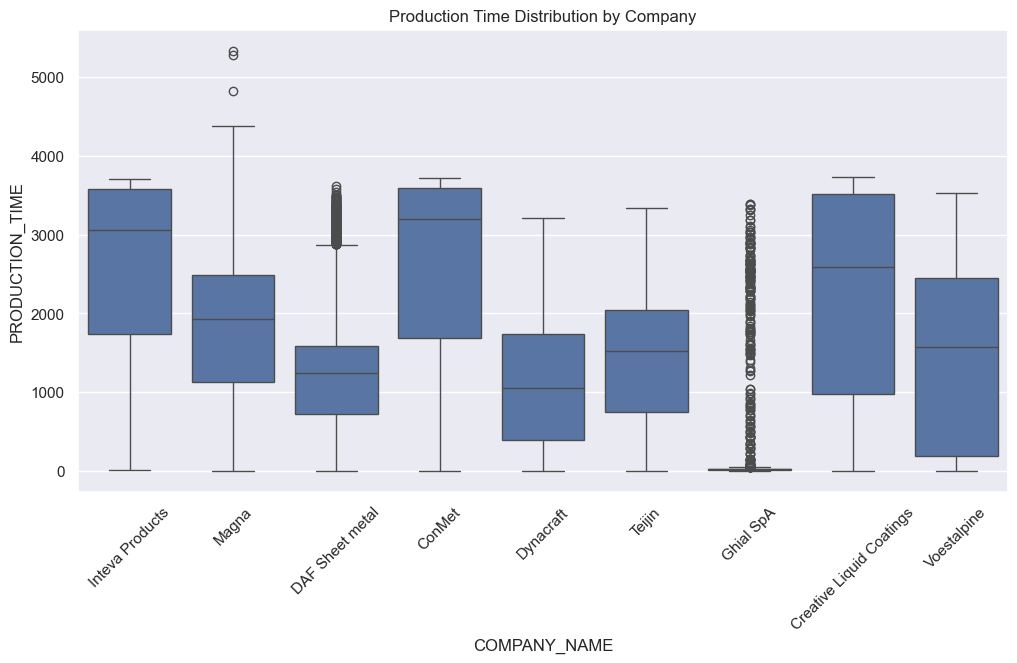

In [50]:
# Boxplot: Production Time by Company Name
plt.figure(figsize=(12, 6))
sns.boxplot(x='COMPANY_NAME', y='PRODUCTION_TIME', data=df)
plt.xticks(rotation=45)
plt.title("Production Time Distribution by Company")
plt.show()


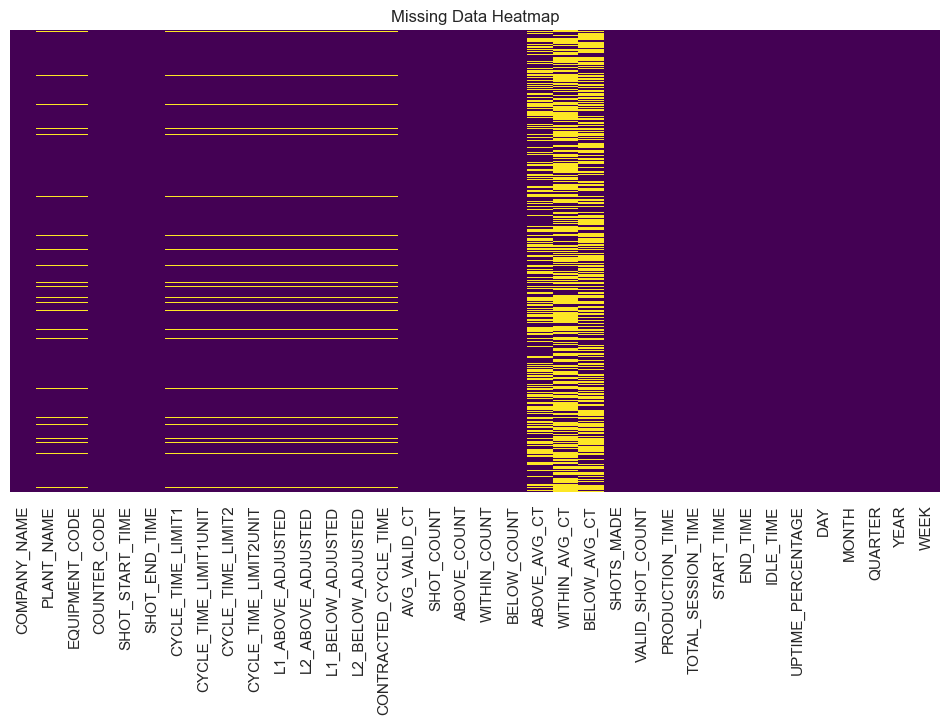

In [51]:
# Missing Data Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()


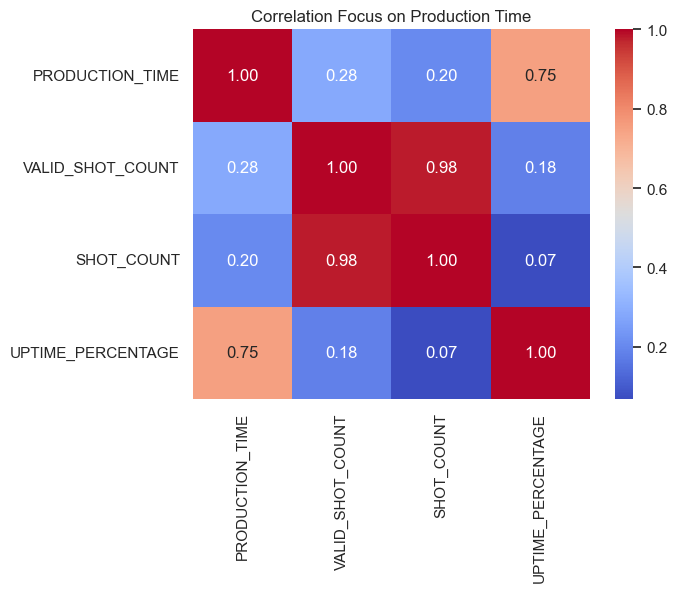

In [52]:
# Correlation: Production Time vs Other Variables
focus_corr = df[['PRODUCTION_TIME', 'VALID_SHOT_COUNT', 'SHOT_COUNT', 'UPTIME_PERCENTAGE']].corr()
sns.heatmap(focus_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Focus on Production Time")
plt.show()


In [53]:
#benchmarking cycle times

cycle_time_performance = df.groupby(['COMPANY_NAME','YEAR', 'MONTH']).agg({
    'WITHIN_COUNT': 'mean',  # % within limits
    'ABOVE_COUNT': 'mean',   # % above limits
    'BELOW_COUNT': 'mean'    # % below limits
}).reset_index()

print(cycle_time_performance)   

   COMPANY_NAME  YEAR   MONTH  WITHIN_COUNT  ABOVE_COUNT  BELOW_COUNT
0        ConMet  2020  202004      0.000000     0.000000     1.000000
1        ConMet  2024  202403     14.382567     0.142857     5.658596
2        ConMet  2024  202404     20.288023     0.122624     1.557985
3        ConMet  2024  202405     16.429549     0.194254     2.381669
4        ConMet  2024  202406     21.331230     0.197161     0.425868
..          ...   ...     ...           ...          ...          ...
93       Teijin  2024  202410      0.503686     0.832924     2.852580
94       Teijin  2024  202411      0.372990     0.700965     3.051447
95       Teijin  2024  202412      0.272727     1.888112     1.363636
96  Voestalpine  2024  202411      0.000000     0.000000     0.000000
97  Voestalpine  2024  202412      0.043796   118.416058     0.759124

[98 rows x 6 columns]


In [54]:
#ben chmarking uptime   

uptime_performance = df.groupby(['COMPANY_NAME','YEAR', 'MONTH']).agg({
    'UPTIME_PERCENTAGE': 'mean'}).reset_index()

print(uptime_performance)

   COMPANY_NAME  YEAR   MONTH  UPTIME_PERCENTAGE
0        ConMet  2020  202004         100.000000
1        ConMet  2024  202403          77.998160
2        ConMet  2024  202404          77.724068
3        ConMet  2024  202405          73.506881
4        ConMet  2024  202406          76.737445
..          ...   ...     ...                ...
93       Teijin  2024  202410          53.609312
94       Teijin  2024  202411          55.369421
95       Teijin  2024  202412          56.021399
96  Voestalpine  2024  202411           8.350000
97  Voestalpine  2024  202412          62.415547

[98 rows x 4 columns]


In [55]:
#shot count performance

df['VALID_SHOT_PERCENTAGE'] = 100* (df['VALID_SHOT_COUNT']) / df['SHOT_COUNT']

shot_performance = df.groupby(['YEAR', 'MONTH']).agg({
    'VALID_SHOT_PERCENTAGE': 'mean'}).reset_index()

print(shot_performance)

    YEAR   MONTH  VALID_SHOT_PERCENTAGE
0   2020  202004              84.978403
1   2022  202201              88.235294
2   2022  202202              85.714286
3   2022  202204              72.840325
4   2022  202205              78.503010
5   2022  202206              55.708061
6   2023  202304              94.098908
7   2023  202305              83.666152
8   2023  202306              85.135924
9   2023  202307              85.639597
10  2023  202308              66.982732
11  2023  202309              53.183600
12  2023  202310              51.029662
13  2023  202311              76.408655
14  2023  202312              56.004762
15  2024  202401              55.802810
16  2024  202402              53.714953
17  2024  202403              78.562852
18  2024  202404              75.628177
19  2024  202405              76.035953
20  2024  202406              78.672336
21  2024  202407              79.868859
22  2024  202408              78.551656
23  2024  202409              78.596542


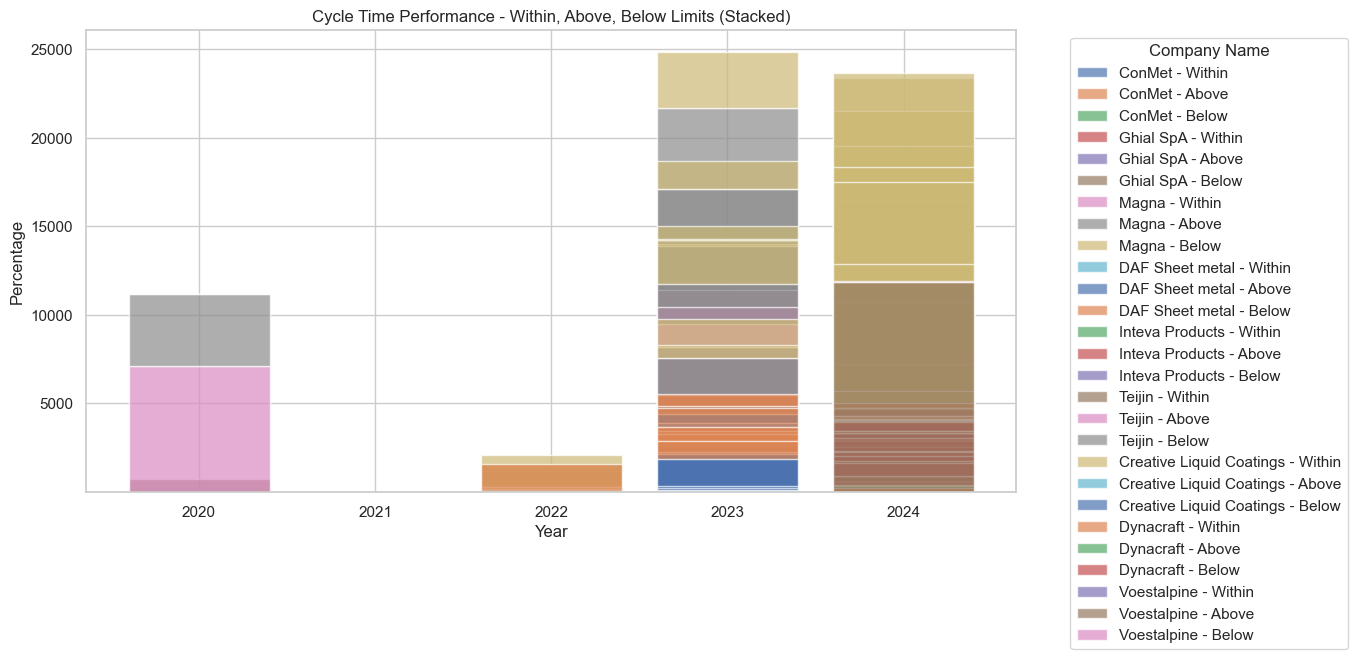

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plot
sns.set(style="whitegrid")

# Create a dataframe with percentages for stacking
cycle_time_performance['WITHIN_COUNT_percentage'] = cycle_time_performance['WITHIN_COUNT'] * 100
cycle_time_performance['ABOVE_COUNT_percentage'] = cycle_time_performance['ABOVE_COUNT'] * 100
cycle_time_performance['BELOW_COUNT_percentage'] = cycle_time_performance['BELOW_COUNT'] * 100

# Group by YEAR and COMPANY_NAME to aggregate the data
df_aggregated = cycle_time_performance.groupby(['YEAR', 'COMPANY_NAME', 'MONTH']).agg({
    'WITHIN_COUNT_percentage': 'mean',
    'ABOVE_COUNT_percentage': 'mean',
    'BELOW_COUNT_percentage': 'mean'
}).reset_index()

# Plotting the stacked bar chart
plt.figure(figsize=(12, 6))

# We use a seaborn barplot and adjust for stacking by plotting multiple bars
companies = df_aggregated['COMPANY_NAME'].unique()

# Plot each company's data with stacked bars
for company in companies:
    company_data = df_aggregated[df_aggregated['COMPANY_NAME'] == company]
    plt.bar(company_data['YEAR'], company_data['WITHIN_COUNT_percentage'], label=f"{company} - Within", alpha=0.7)
    plt.bar(company_data['YEAR'], company_data['ABOVE_COUNT_percentage'], bottom=company_data['WITHIN_COUNT_percentage'], label=f"{company} - Above", alpha=0.7)
    plt.bar(company_data['YEAR'], company_data['BELOW_COUNT_percentage'], bottom=company_data['WITHIN_COUNT_percentage'] + company_data['ABOVE_COUNT_percentage'], label=f"{company} - Below", alpha=0.7)

# Adding labels and title
plt.title("Cycle Time Performance - Within, Above, Below Limits (Stacked)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="Company Name", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


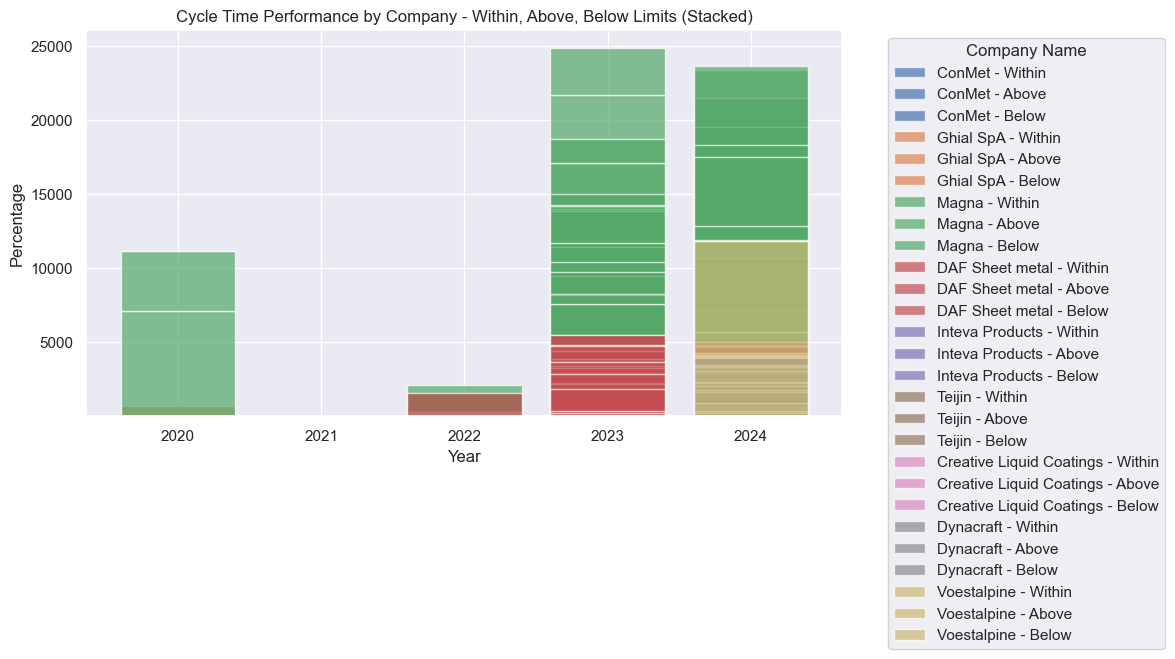

In [57]:
#lets separate it by company 

sns.set(style="darkgrid")

cycle_time_performance['WITHIN_COUNT_percentage'] = cycle_time_performance['WITHIN_COUNT'] * 100
cycle_time_performance['ABOVE_COUNT_percentage'] = cycle_time_performance['ABOVE_COUNT'] * 100
cycle_time_performance['BELOW_COUNT_percentage'] = cycle_time_performance['BELOW_COUNT'] * 100

df_aggregated = cycle_time_performance.groupby(['YEAR', 'COMPANY_NAME','MONTH']).agg({  
    'WITHIN_COUNT_percentage': 'mean',
    'ABOVE_COUNT_percentage': 'mean',
    'BELOW_COUNT_percentage': 'mean'
}).reset_index()

companies = df_aggregated['COMPANY_NAME'].unique()

plt.figure(figsize=(12, 6))

for i, company in enumerate(companies):
    company_data = df_aggregated[df_aggregated['COMPANY_NAME'] == company]
    plt.bar(company_data['YEAR'], company_data['WITHIN_COUNT_percentage'], label=f"{company} - Within", alpha=0.7, color=f"C{i}")
    plt.bar(company_data['YEAR'], company_data['ABOVE_COUNT_percentage'], bottom=company_data['WITHIN_COUNT_percentage'], label=f"{company} - Above", alpha=0.7, color=f"C{i}")
    plt.bar(company_data['YEAR'], company_data['BELOW_COUNT_percentage'], bottom=company_data['WITHIN_COUNT_percentage'] + company_data['ABOVE_COUNT_percentage'], label=f"{company} - Below", alpha=0.7, color=f"C{i}")
    
plt.title("Cycle Time Performance by Company - Within, Above, Below Limits (Stacked)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="Company Name", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

   YEAR     COMPANY_NAME  BELOW_COUNT_percentage  WITHIN_COUNT_percentage  \
0  2023  DAF Sheet metal               26.805668                23.762795   
1  2023        Ghial SpA               87.046172                12.575598   
2  2023  Inteva Products                     NaN                      NaN   
3  2023            Magna               16.275392                44.750028   
4  2023           Teijin                     NaN                      NaN   

   ABOVE_COUNT_percentage  
0               49.431537  
1                0.378230  
2                     NaN  
3               38.974580  
4                     NaN  
No data for ConMet in 2023
No data for Creative Liquid Coatings in 2023
No data for Dynacraft in 2023
No data for Voestalpine in 2023


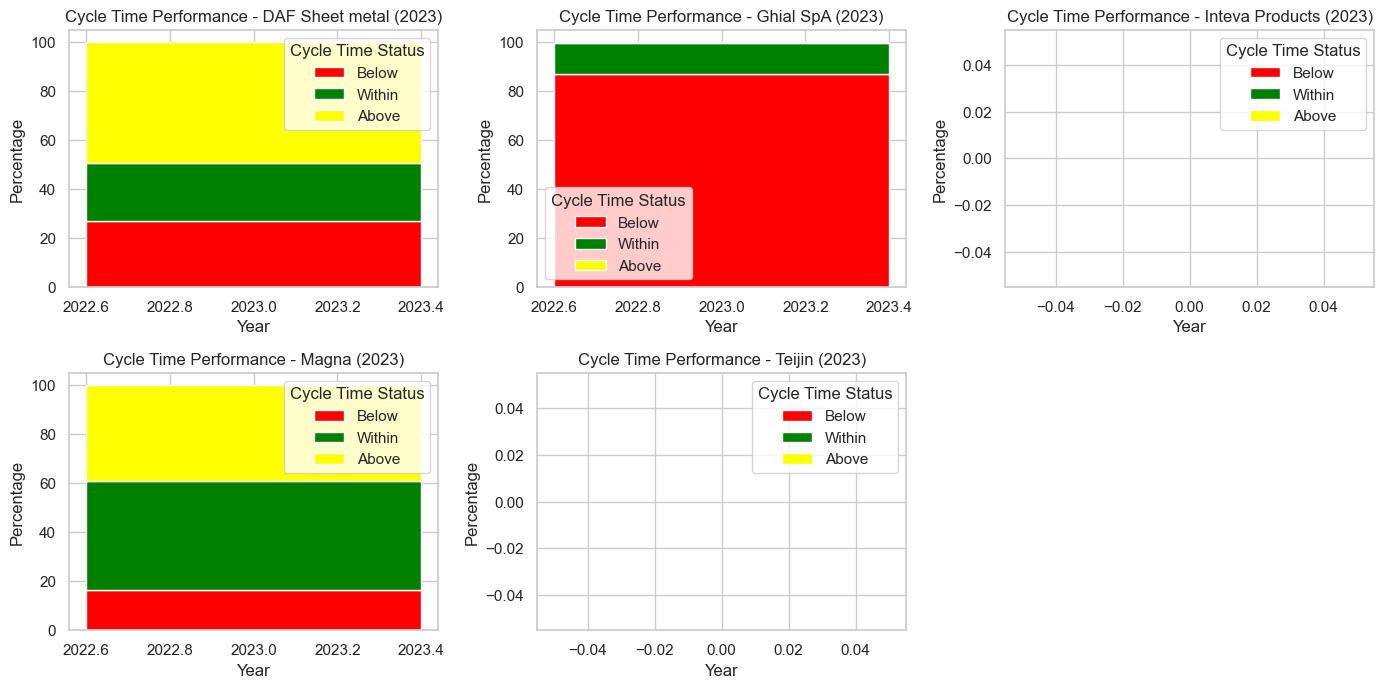

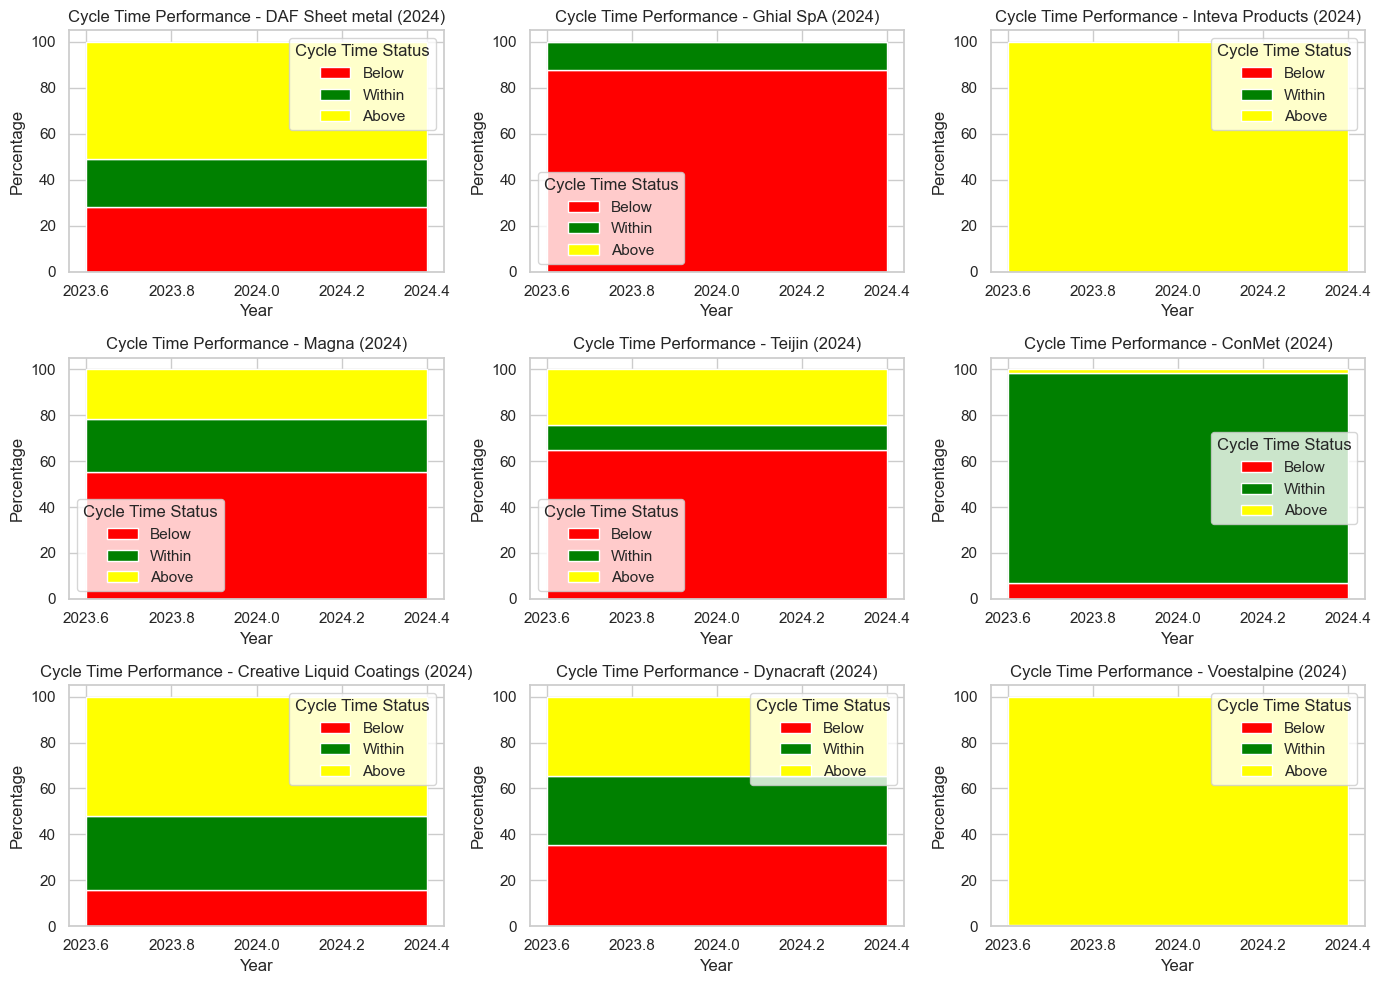

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for the plot
sns.set(style="whitegrid")

# Assuming cycle_time_performance already contains valid counts for the categories
# Calculate the total count for each year and company
cycle_time_performance['TOTAL_COUNT'] = cycle_time_performance[['ABOVE_COUNT', 'WITHIN_COUNT', 'BELOW_COUNT']].sum(axis=1)

# Recalculate the percentages correctly
cycle_time_performance['BELOW_COUNT_percentage'] = (cycle_time_performance['BELOW_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['WITHIN_COUNT_percentage'] = (cycle_time_performance['WITHIN_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['ABOVE_COUNT_percentage'] = (cycle_time_performance['ABOVE_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100

# Filter for the years 2023 and 2024
cycle_time_performance = cycle_time_performance[cycle_time_performance['YEAR'].isin([2023, 2024])]

# Group by YEAR and COMPANY_NAME to get aggregated data
df_aggregated = cycle_time_performance.groupby(['YEAR', 'COMPANY_NAME']).agg({
    'BELOW_COUNT_percentage': 'mean',
    'WITHIN_COUNT_percentage': 'mean',
    'ABOVE_COUNT_percentage': 'mean'
}).reset_index()

# Print the aggregated data to verify
print(df_aggregated.head())

# Get list of unique companies
companies = df_aggregated['COMPANY_NAME'].unique()

# Create separate plots for 2023 and 2024
for year in [2023, 2024]:
    plt.figure(figsize=(14, 10))
    
    for i, company in enumerate(companies, 1):
        company_data = df_aggregated[(df_aggregated['COMPANY_NAME'] == company) & (df_aggregated['YEAR'] == year)]
        
        if company_data.empty:
            print(f"No data for {company} in {year}")
            continue  # Skip if no data is found
        
        # Plot stacked bars in the correct order
        plt.subplot(3, 3, i)  # Adjust the number of rows and columns as needed
        plt.bar(company_data['YEAR'], company_data['BELOW_COUNT_percentage'], color='red', label='Below')
        plt.bar(company_data['YEAR'], company_data['WITHIN_COUNT_percentage'], color='green', 
                bottom=company_data['BELOW_COUNT_percentage'], label='Within')
        plt.bar(company_data['YEAR'], company_data['ABOVE_COUNT_percentage'], color='yellow', 
                bottom=company_data['BELOW_COUNT_percentage'] + company_data['WITHIN_COUNT_percentage'], label='Above')
        
        # Add titles and labels
        plt.title(f"Cycle Time Performance - {company} ({year})")
        plt.xlabel("Year")
        plt.ylabel("Percentage")
        plt.legend(title="Cycle Time Status")
    
    # Adjust layout to make space for all subplots
    plt.tight_layout()
    plt.show()


In [59]:
print(company_data.columns)


Index(['YEAR', 'COMPANY_NAME', 'BELOW_COUNT_percentage',
       'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
      dtype='object')


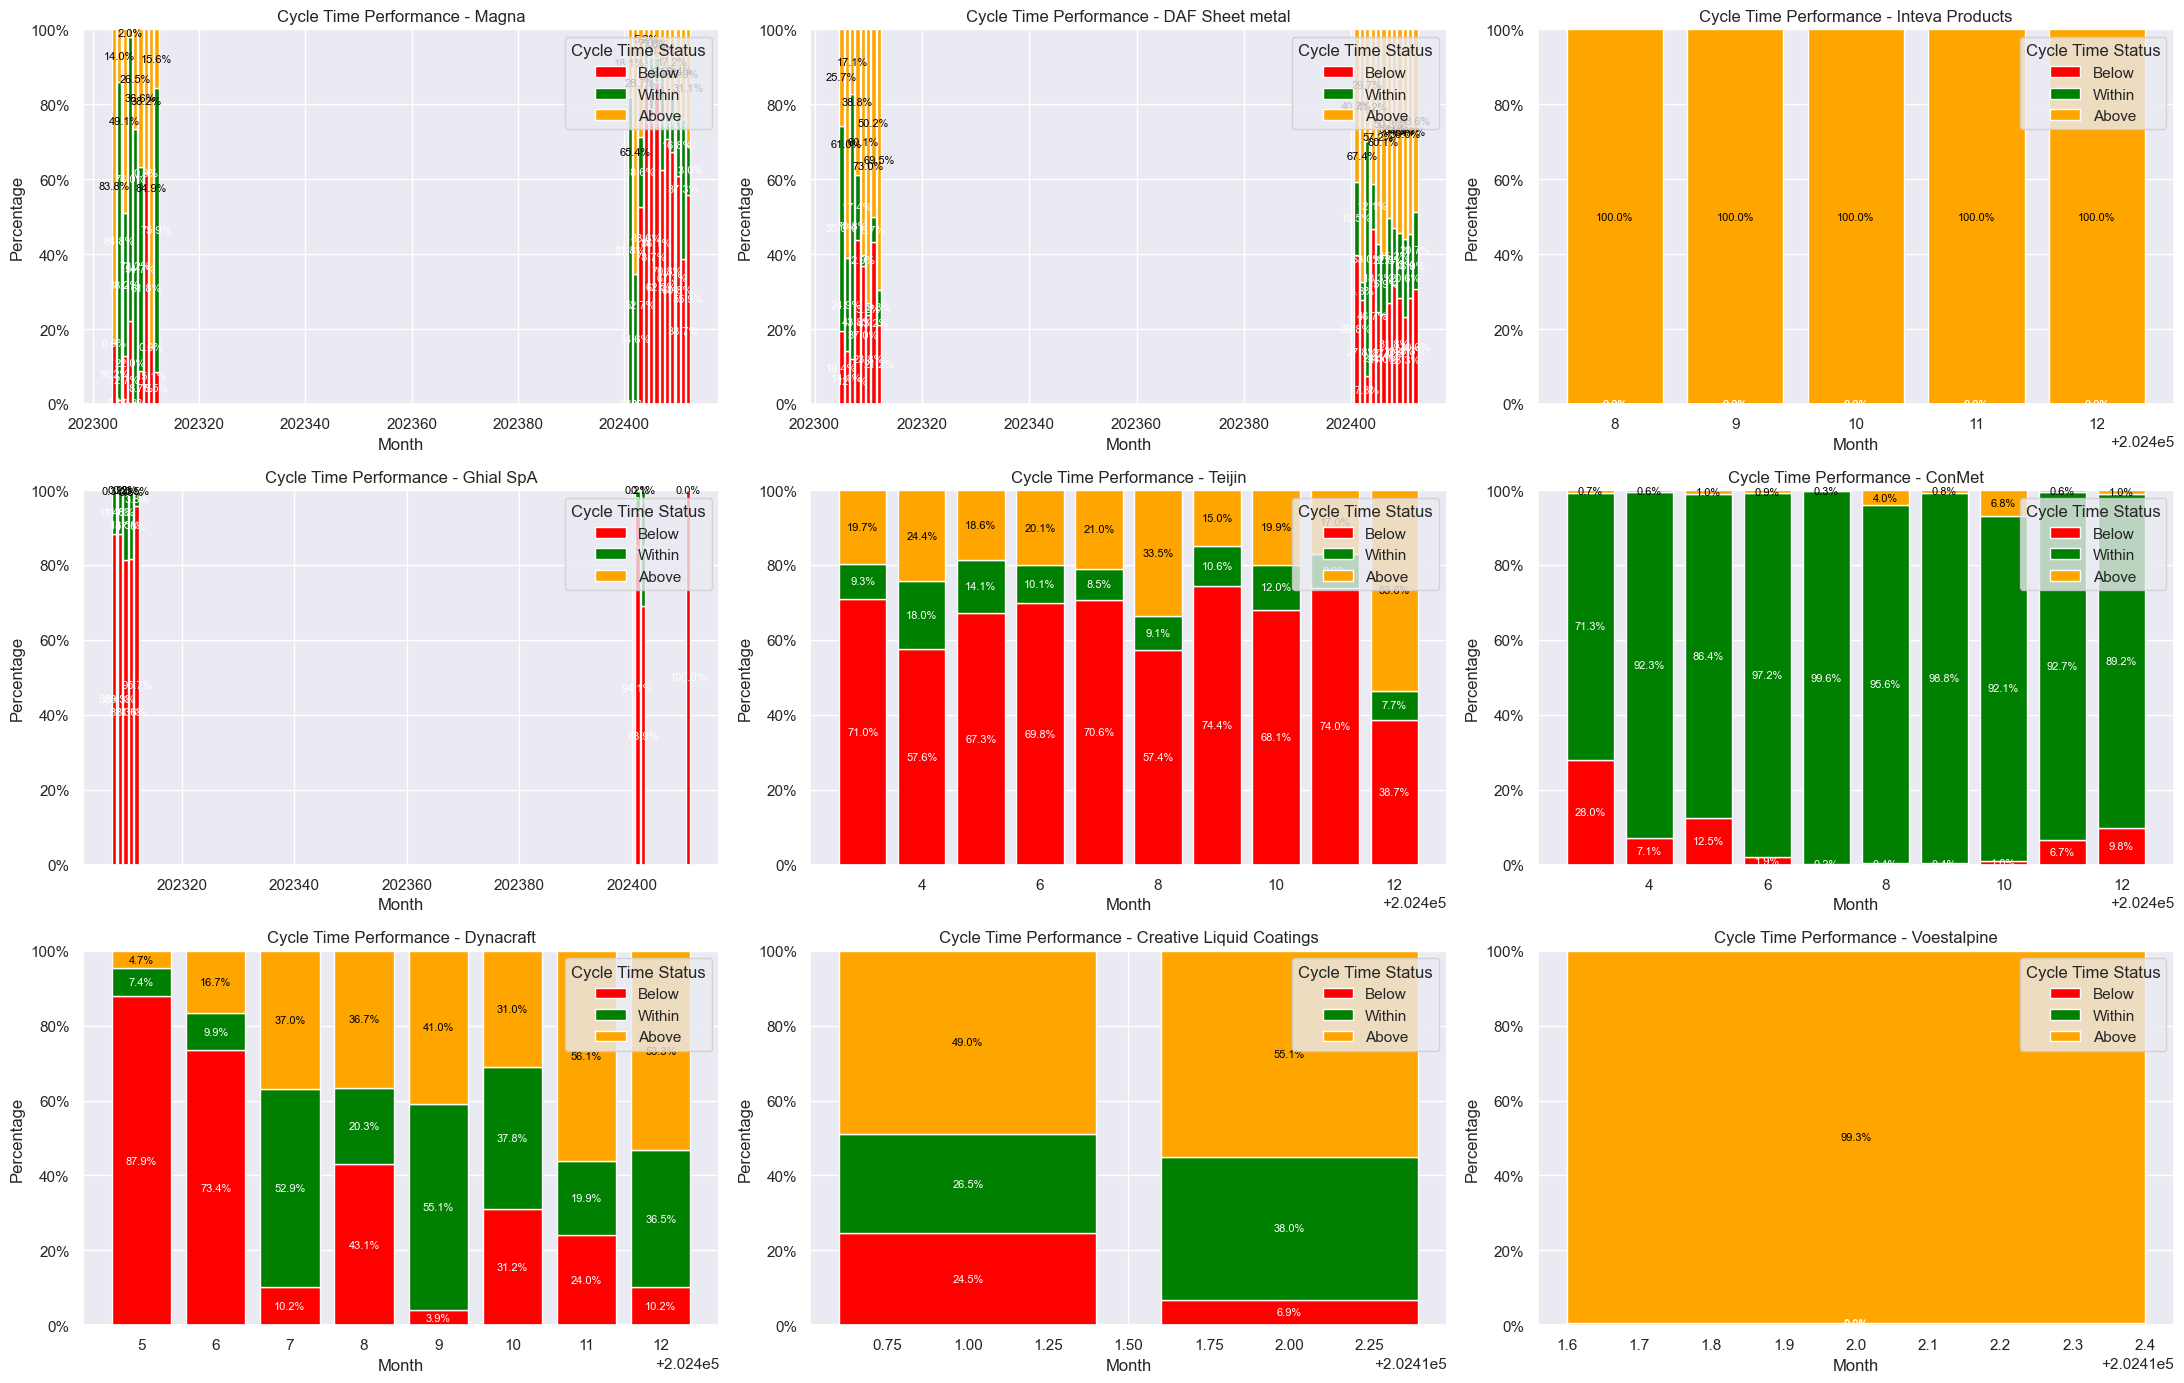

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np

# Set style for the plot
sns.set(style="darkgrid")

# Assuming cycle_time_performance already contains valid counts for the categories
# Calculate the total count for each year, month, and company
cycle_time_performance['TOTAL_COUNT'] = cycle_time_performance[['ABOVE_COUNT', 'WITHIN_COUNT', 'BELOW_COUNT']].sum(axis=1)

# Calculate the percentage for each category by dividing each count by the total count and multiplying by 100
cycle_time_performance['ABOVE_COUNT_percentage'] = (cycle_time_performance['ABOVE_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['WITHIN_COUNT_percentage'] = (cycle_time_performance['WITHIN_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['BELOW_COUNT_percentage'] = (cycle_time_performance['BELOW_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100

# Filter the data starting from 2023-04-01 (from the MONTH column in YYYYMM format)
cycle_time_performance_filtered = cycle_time_performance[cycle_time_performance['MONTH'] >= 202304]

# Group by MONTH and COMPANY_NAME to get monthly data
df_aggregated = cycle_time_performance_filtered.groupby(['MONTH', 'COMPANY_NAME']).agg({
    'ABOVE_COUNT_percentage': 'mean',
    'WITHIN_COUNT_percentage': 'mean',
    'BELOW_COUNT_percentage': 'mean'
}).reset_index()

# Reshape the data to a long format (needed for hue usage)
df_long = pd.melt(df_aggregated, id_vars=['MONTH', 'COMPANY_NAME'], 
                  value_vars=['ABOVE_COUNT_percentage', 'WITHIN_COUNT_percentage', 'BELOW_COUNT_percentage'],
                  var_name='Cycle_Time_Status', value_name='Percentage')

# Get list of unique companies
companies = df_aggregated['COMPANY_NAME'].unique()

# Create subplots to display separate bars for each company
plt.figure(figsize=(22, 14))  # Adjusted the size for larger subplots

# Create separate bar charts for each company
for i, company in enumerate(companies):
    company_data = df_long[df_long['COMPANY_NAME'] == company]
    
    plt.subplot(3, 3, i + 1)  # Adjust the number of rows and columns if needed

    # Get unique months in the company data (avoid using all 12 months)
    months = sorted(company_data['MONTH'].unique())
    
    # Initialize bottom for stacking
    bottom = [0] * len(months)
    
    # Plot bars for Below (red)
    below_data = company_data[company_data['Cycle_Time_Status'] == 'BELOW_COUNT_percentage']
    plt.bar(below_data['MONTH'], below_data['Percentage'], color='red', label='Below', bottom=bottom)
    for x, y in zip(below_data['MONTH'], below_data['Percentage']):
        if np.isfinite(y):  # Only plot text if y is a valid number
            plt.text(x, y / 2, f'{y:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    # Update bottom
    bottom = [b + p for b, p in zip(bottom, below_data['Percentage'])]
    
    # Plot bars for Within (green)
    within_data = company_data[company_data['Cycle_Time_Status'] == 'WITHIN_COUNT_percentage']
    plt.bar(within_data['MONTH'], within_data['Percentage'], color='green', label='Within', bottom=bottom)
    for x, y, b in zip(within_data['MONTH'], within_data['Percentage'], bottom):
        if np.isfinite(y):  # Only plot text if y is a valid number
            plt.text(x, b + (y / 2), f'{y:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    # Update bottom
    bottom = [b + p for b, p in zip(bottom, within_data['Percentage'])]
    
    # Plot bars for Above (orange)
    above_data = company_data[company_data['Cycle_Time_Status'] == 'ABOVE_COUNT_percentage']
    plt.bar(above_data['MONTH'], above_data['Percentage'], color='orange', label='Above', bottom=bottom)
    for x, y, b in zip(above_data['MONTH'], above_data['Percentage'], bottom):
        if np.isfinite(y):  # Only plot text if y is a valid number
            plt.text(x, b + (y / 2), f'{y:.1f}%', ha='center', va='center', color='black', fontsize=8)
    
    # Set the title and labels
    plt.title(f"Cycle Time Performance - {company}")
    plt.xlabel("Month")
    plt.ylabel("Percentage")
    
    # Manually set y-axis format to display percentages
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    # Set y-axis limit to ensure it always goes to 100%
    plt.ylim(0, 100)

    # Add a legend
    plt.legend(title="Cycle Time Status", loc='upper right')

plt.tight_layout()
plt.show()


2023 - Month: 202305, Cycle Time Status: Below, Percentage: 19.4%
2023 - Month: 202306, Cycle Time Status: Below, Percentage: 14.1%
2023 - Month: 202307, Cycle Time Status: Below, Percentage: 12.1%
2023 - Month: 202308, Cycle Time Status: Below, Percentage: 43.8%
2023 - Month: 202309, Cycle Time Status: Below, Percentage: 37.0%
2023 - Month: 202310, Cycle Time Status: Below, Percentage: 23.8%
2023 - Month: 202311, Cycle Time Status: Below, Percentage: 43.2%
2023 - Month: 202312, Cycle Time Status: Below, Percentage: 21.2%
2023 - Month: 202305, Cycle Time Status: Within, Percentage: 55.0%
2023 - Month: 202306, Cycle Time Status: Within, Percentage: 24.9%
2023 - Month: 202307, Cycle Time Status: Within, Percentage: 70.8%
2023 - Month: 202308, Cycle Time Status: Within, Percentage: 17.4%
2023 - Month: 202309, Cycle Time Status: Within, Percentage: 2.9%
2023 - Month: 202310, Cycle Time Status: Within, Percentage: 3.2%
2023 - Month: 202311, Cycle Time Status: Within, Percentage: 6.7%
2023 -

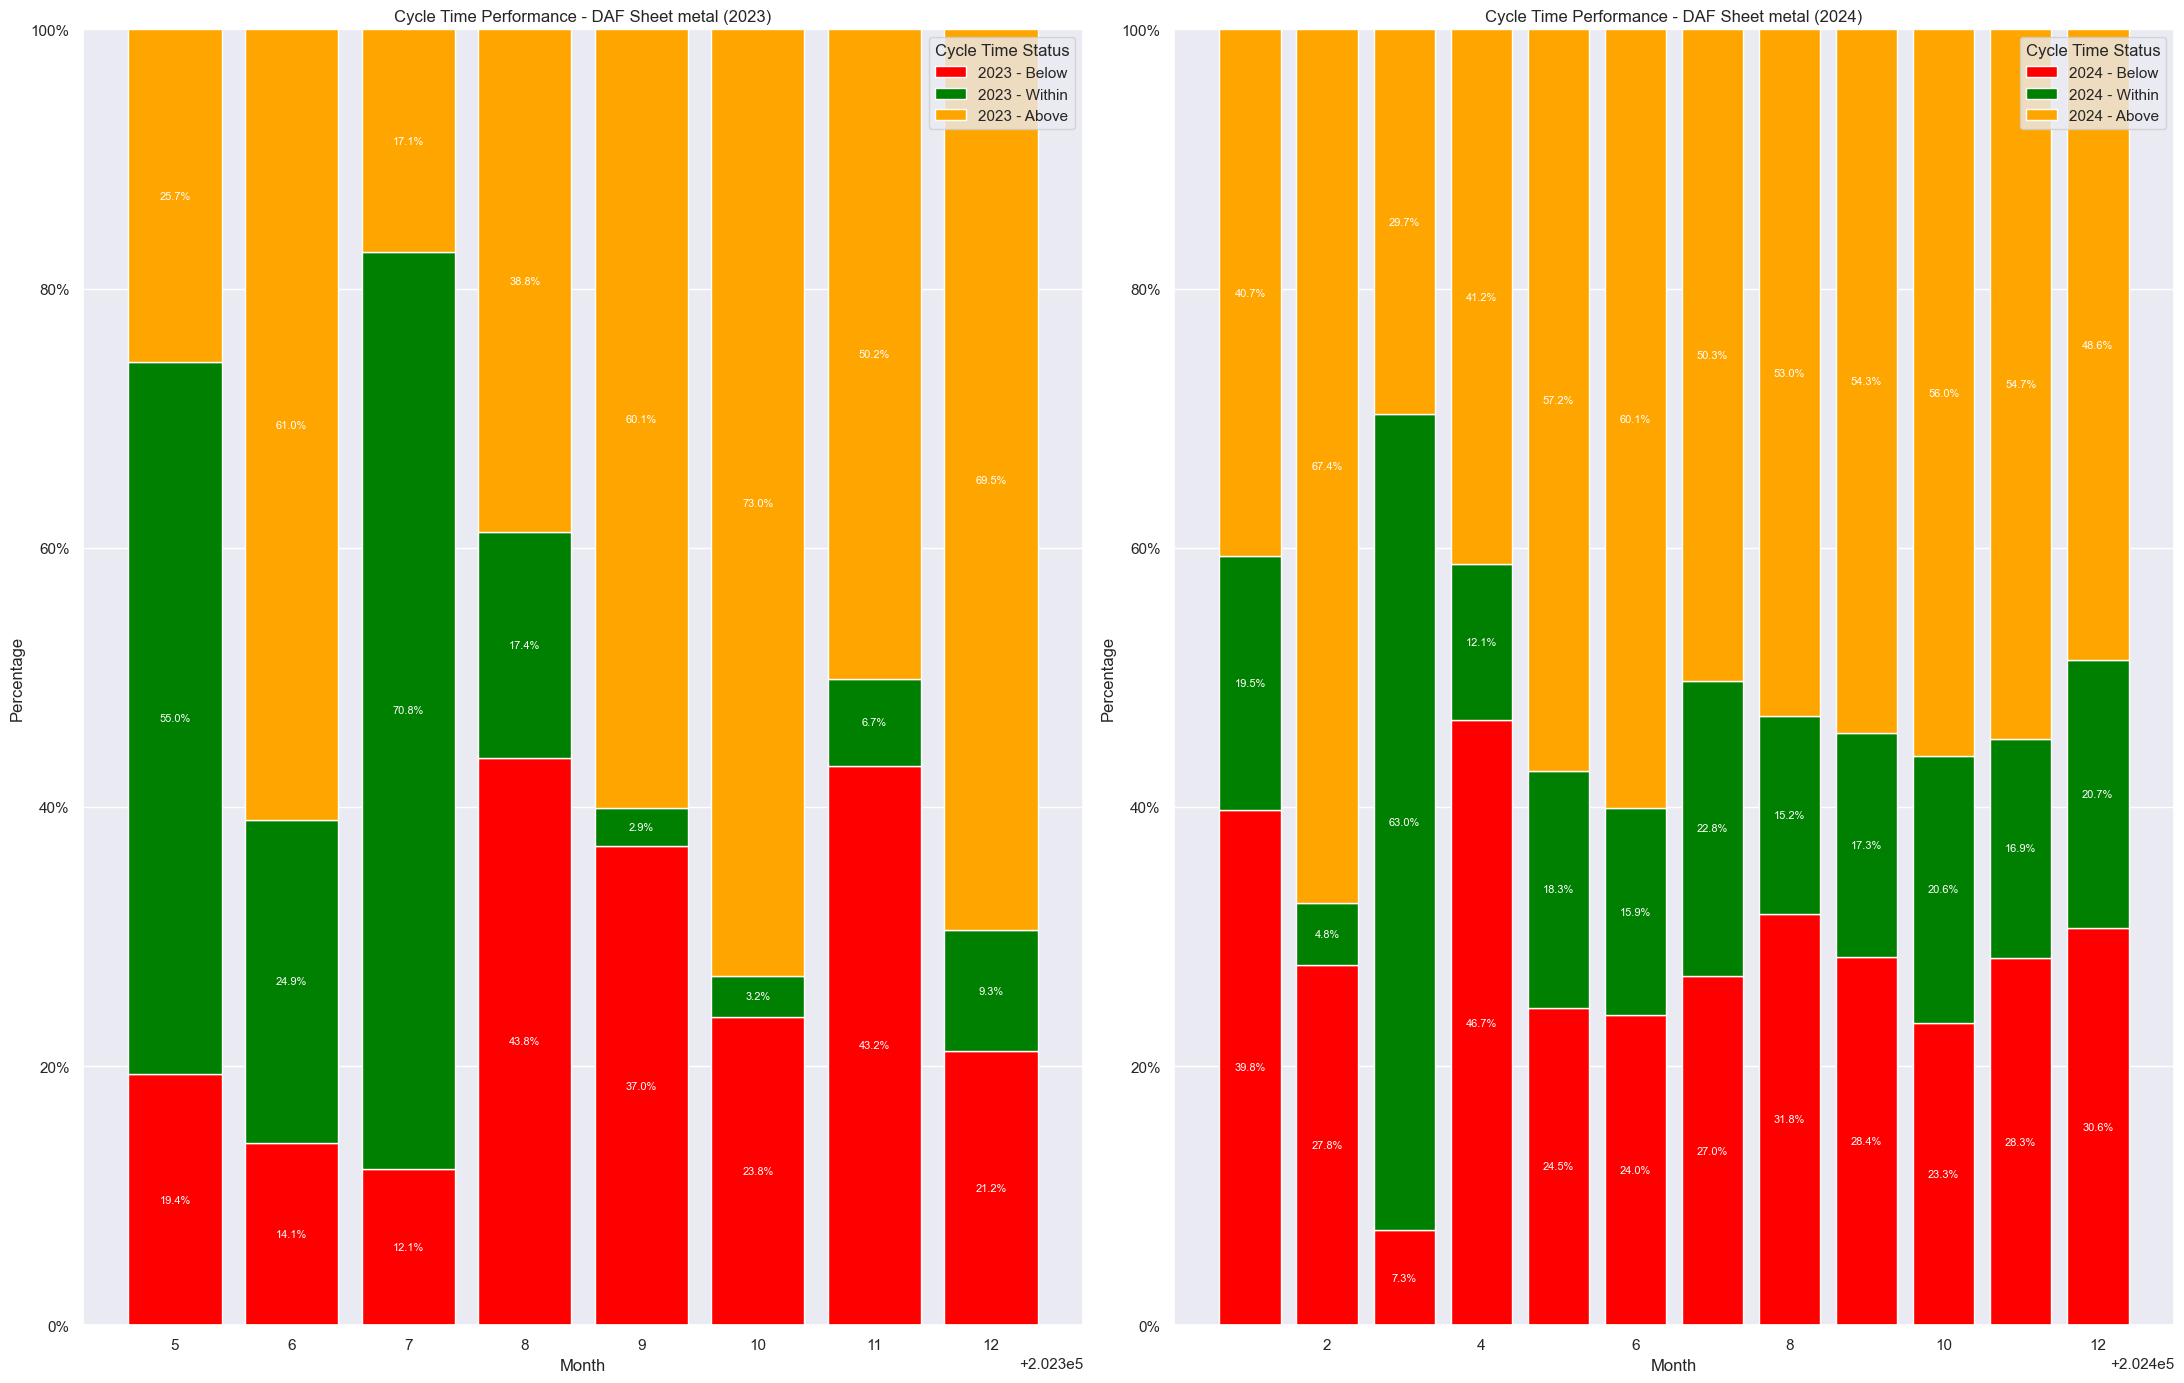

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np

# Set style for the plot
sns.set(style="darkgrid")

# Assuming cycle_time_performance already contains valid counts for the categories
# Calculate the total count for each year, month, and company
cycle_time_performance['TOTAL_COUNT'] = cycle_time_performance[['ABOVE_COUNT', 'WITHIN_COUNT', 'BELOW_COUNT']].sum(axis=1)

# Calculate the percentage for each category by dividing each count by the total count and multiplying by 100
cycle_time_performance['ABOVE_COUNT_percentage'] = (cycle_time_performance['ABOVE_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['WITHIN_COUNT_percentage'] = (cycle_time_performance['WITHIN_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['BELOW_COUNT_percentage'] = (cycle_time_performance['BELOW_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100

# Filter the data starting from 2023-04-01 (from the MONTH column in YYYYMM format)
cycle_time_performance_filtered = cycle_time_performance[cycle_time_performance['MONTH'] >= 202304]

# Filter the data for "DAF Sheet Metal"
cycle_time_performance_daf = cycle_time_performance_filtered[cycle_time_performance_filtered['COMPANY_NAME'] == 'DAF Sheet metal']

# Group by MONTH and COMPANY_NAME to get monthly data
df_aggregated = cycle_time_performance_daf.groupby(['MONTH', 'COMPANY_NAME']).agg({
    'ABOVE_COUNT_percentage': 'mean',
    'WITHIN_COUNT_percentage': 'mean',
    'BELOW_COUNT_percentage': 'mean'
}).reset_index()

# Reshape the data to a long format (needed for hue usage)
df_long = pd.melt(df_aggregated, id_vars=['MONTH', 'COMPANY_NAME'], 
                  value_vars=['ABOVE_COUNT_percentage', 'WITHIN_COUNT_percentage', 'BELOW_COUNT_percentage'],
                  var_name='Cycle_Time_Status', value_name='Percentage')

# Create subplots for the DAF Sheet Metal data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14))  # Create two subplots side by side

# Only process DAF Sheet Metal data
company_data = df_long[df_long['COMPANY_NAME'] == 'DAF Sheet metal']

# Get the unique years and months
company_data['YEAR'] = company_data['MONTH'].astype(str).str[:4].astype(int)

# Filter data for 2023 and 2024
data_2023 = company_data[company_data['YEAR'] == 2023]
data_2024 = company_data[company_data['YEAR'] == 2024]

# Initialize bottom for stacking for 2023
bottom_2023 = [0] * len(data_2023['MONTH'].unique())

# Plot 2023 Data on the first subplot
months_2023 = sorted(data_2023['MONTH'].unique())
for cycle_status, color, label in zip(['BELOW_COUNT_percentage', 'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
                                      ['red', 'green', 'orange'],
                                      ['Below', 'Within', 'Above']):
    cycle_data = data_2023[data_2023['Cycle_Time_Status'] == cycle_status]
    bars = ax1.bar(cycle_data['MONTH'], cycle_data['Percentage'], color=color, label=f'2023 - {label}', bottom=bottom_2023)
    
    # Add percentage text on the bars and print out the values
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if np.isfinite(yval):  # Only plot text if yval is valid
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 + bottom_2023[i],
                     f'{yval:.1f}%', ha='center', va='center', color='white', fontsize=8)
            
            # Print the percentages as output
            print(f"2023 - Month: {cycle_data['MONTH'].iloc[i]}, Cycle Time Status: {label}, Percentage: {yval:.1f}%")
    
    bottom_2023 = [b + p for b, p in zip(bottom_2023, cycle_data['Percentage'])]

# Set the title and labels for the 2023 plot
ax1.set_title(f"Cycle Time Performance - DAF Sheet metal (2023)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Percentage")

# Manually set y-axis format to display percentages
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Set y-axis limit to ensure it always goes to 100%
ax1.set_ylim(0, 100)

# Add a legend for the 2023 plot
ax1.legend(title="Cycle Time Status", loc='upper right')

# Initialize bottom for stacking for 2024
bottom_2024 = [0] * len(data_2024['MONTH'].unique())

# Plot 2024 Data on the second subplot
months_2024 = sorted(data_2024['MONTH'].unique())
for cycle_status, color, label in zip(['BELOW_COUNT_percentage', 'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
                                      ['red', 'green', 'orange'],
                                      ['Below', 'Within', 'Above']):
    cycle_data = data_2024[data_2024['Cycle_Time_Status'] == cycle_status]
    bars = ax2.bar(cycle_data['MONTH'], cycle_data['Percentage'], color=color, label=f'2024 - {label}', bottom=bottom_2024)
    
    # Add percentage text on the bars and print out the values
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if np.isfinite(yval):  # Only plot text if yval is valid
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 + bottom_2024[i],
                     f'{yval:.1f}%', ha='center', va='center', color='white', fontsize=8)
            
            # Print the percentages as output
            print(f"2024 - Month: {cycle_data['MONTH'].iloc[i]}, Cycle Time Status: {label}, Percentage: {yval:.1f}%")
    
    bottom_2024 = [b + p for b, p in zip(bottom_2024, cycle_data['Percentage'])]

# Set the title and labels for the 2024 plot
ax2.set_title(f"Cycle Time Performance - DAF Sheet metal (2024)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Percentage")

# Manually set y-axis format to display percentages
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Set y-axis limit to ensure it always goes to 100%
ax2.set_ylim(0, 100)

# Add a legend for the 2024 plot
ax2.legend(title="Cycle Time Status", loc='upper right')

plt.tight_layout()
plt.show()


2023 - Month: 202304, Cycle Time Status: Below, Percentage: 16.2%
2023 - Month: 202305, Cycle Time Status: Below, Percentage: 1.1%
2023 - Month: 202306, Cycle Time Status: Below, Percentage: 12.7%
2023 - Month: 202307, Cycle Time Status: Below, Percentage: 22.0%
2023 - Month: 202308, Cycle Time Status: Below, Percentage: 0.3%
2023 - Month: 202309, Cycle Time Status: Below, Percentage: 8.7%
2023 - Month: 202310, Cycle Time Status: Below, Percentage: 61.8%
2023 - Month: 202311, Cycle Time Status: Below, Percentage: 15.1%
2023 - Month: 202312, Cycle Time Status: Below, Percentage: 8.5%
2023 - Month: 202304, Cycle Time Status: Within, Percentage: 0.0%
2023 - Month: 202305, Cycle Time Status: Within, Percentage: 84.8%
2023 - Month: 202306, Cycle Time Status: Within, Percentage: 38.2%
2023 - Month: 202307, Cycle Time Status: Within, Percentage: 76.0%
2023 - Month: 202308, Cycle Time Status: Within, Percentage: 73.2%
2023 - Month: 202309, Cycle Time Status: Within, Percentage: 54.7%
2023 - Mo

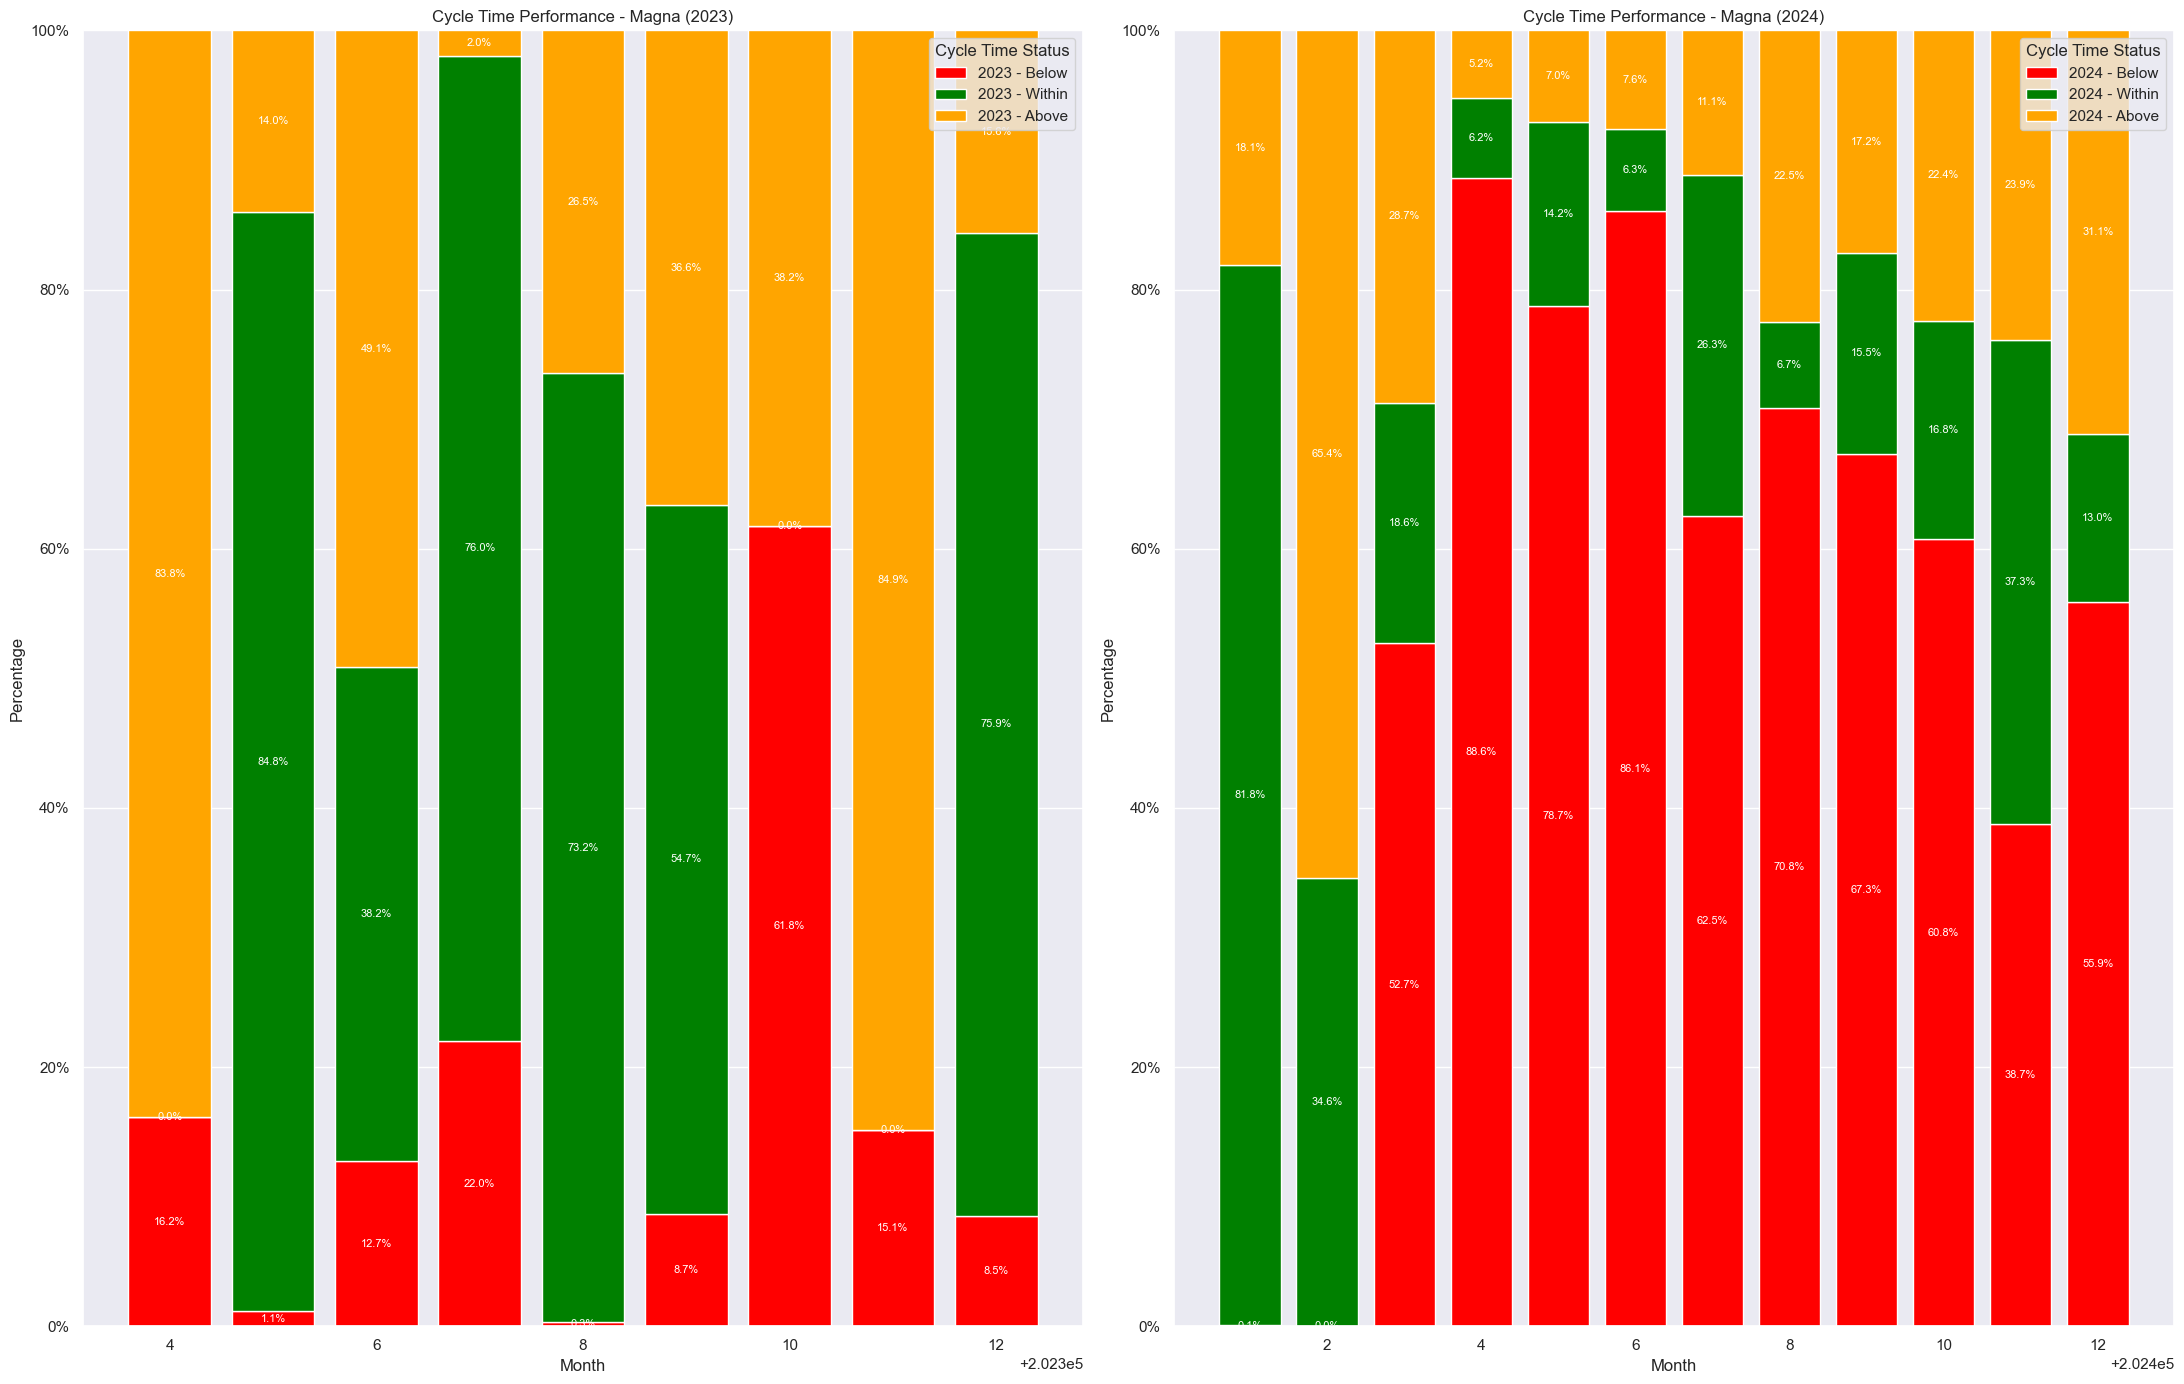

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np

# Set style for the plot
sns.set(style="darkgrid")

# Assuming cycle_time_performance already contains valid counts for the categories
# Calculate the total count for each year, month, and company
cycle_time_performance['TOTAL_COUNT'] = cycle_time_performance[['ABOVE_COUNT', 'WITHIN_COUNT', 'BELOW_COUNT']].sum(axis=1)

# Calculate the percentage for each category by dividing each count by the total count and multiplying by 100
cycle_time_performance['ABOVE_COUNT_percentage'] = (cycle_time_performance['ABOVE_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['WITHIN_COUNT_percentage'] = (cycle_time_performance['WITHIN_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['BELOW_COUNT_percentage'] = (cycle_time_performance['BELOW_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100

# Filter the data starting from 2023-04-01 (from the MONTH column in YYYYMM format)
cycle_time_performance_filtered = cycle_time_performance[cycle_time_performance['MONTH'] >= 202304]

# Filter the data for "DAF Sheet Metal"
cycle_time_performance_daf = cycle_time_performance_filtered[cycle_time_performance_filtered['COMPANY_NAME'] == 'Magna']

# Group by MONTH and COMPANY_NAME to get monthly data
df_aggregated = cycle_time_performance_daf.groupby(['MONTH', 'COMPANY_NAME']).agg({
    'ABOVE_COUNT_percentage': 'mean',
    'WITHIN_COUNT_percentage': 'mean',
    'BELOW_COUNT_percentage': 'mean'
}).reset_index()

# Reshape the data to a long format (needed for hue usage)
df_long = pd.melt(df_aggregated, id_vars=['MONTH', 'COMPANY_NAME'], 
                  value_vars=['ABOVE_COUNT_percentage', 'WITHIN_COUNT_percentage', 'BELOW_COUNT_percentage'],
                  var_name='Cycle_Time_Status', value_name='Percentage')

# Create subplots for the DAF Sheet Metal data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14))  # Create two subplots side by side

# Only process DAF Sheet Metal data
company_data = df_long[df_long['COMPANY_NAME'] == 'Magna']

# Get the unique years and months
company_data['YEAR'] = company_data['MONTH'].astype(str).str[:4].astype(int)

# Filter data for 2023 and 2024
data_2023 = company_data[company_data['YEAR'] == 2023]
data_2024 = company_data[company_data['YEAR'] == 2024]

# Initialize bottom for stacking for 2023
bottom_2023 = [0] * len(data_2023['MONTH'].unique())

# Plot 2023 Data on the first subplot
months_2023 = sorted(data_2023['MONTH'].unique())
for cycle_status, color, label in zip(['BELOW_COUNT_percentage', 'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
                                      ['red', 'green', 'orange'],
                                      ['Below', 'Within', 'Above']):
    cycle_data = data_2023[data_2023['Cycle_Time_Status'] == cycle_status]
    bars = ax1.bar(cycle_data['MONTH'], cycle_data['Percentage'], color=color, label=f'2023 - {label}', bottom=bottom_2023)
    
    # Add percentage text on the bars and print out the values
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if np.isfinite(yval):  # Only plot text if yval is valid
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 + bottom_2023[i],
                     f'{yval:.1f}%', ha='center', va='center', color='white', fontsize=8)
            
            # Print the percentages as output
            print(f"2023 - Month: {cycle_data['MONTH'].iloc[i]}, Cycle Time Status: {label}, Percentage: {yval:.1f}%")
    
    bottom_2023 = [b + p for b, p in zip(bottom_2023, cycle_data['Percentage'])]

# Set the title and labels for the 2023 plot
ax1.set_title(f"Cycle Time Performance - Magna (2023)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Percentage")

# Manually set y-axis format to display percentages
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Set y-axis limit to ensure it always goes to 100%
ax1.set_ylim(0, 100)

# Add a legend for the 2023 plot
ax1.legend(title="Cycle Time Status", loc='upper right')

# Initialize bottom for stacking for 2024
bottom_2024 = [0] * len(data_2024['MONTH'].unique())

# Plot 2024 Data on the second subplot
months_2024 = sorted(data_2024['MONTH'].unique())
for cycle_status, color, label in zip(['BELOW_COUNT_percentage', 'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
                                      ['red', 'green', 'orange'],
                                      ['Below', 'Within', 'Above']):
    cycle_data = data_2024[data_2024['Cycle_Time_Status'] == cycle_status]
    bars = ax2.bar(cycle_data['MONTH'], cycle_data['Percentage'], color=color, label=f'2024 - {label}', bottom=bottom_2024)
    
    # Add percentage text on the bars and print out the values
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if np.isfinite(yval):  # Only plot text if yval is valid
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 + bottom_2024[i],
                     f'{yval:.1f}%', ha='center', va='center', color='white', fontsize=8)
            
            # Print the percentages as output
            print(f"2024 - Month: {cycle_data['MONTH'].iloc[i]}, Cycle Time Status: {label}, Percentage: {yval:.1f}%")
    
    bottom_2024 = [b + p for b, p in zip(bottom_2024, cycle_data['Percentage'])]

# Set the title and labels for the 2024 plot
ax2.set_title(f"Cycle Time Performance - Magna (2024)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Percentage")

# Manually set y-axis format to display percentages
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Set y-axis limit to ensure it always goes to 100%
ax2.set_ylim(0, 100)

# Add a legend for the 2024 plot
ax2.legend(title="Cycle Time Status", loc='upper right')

plt.tight_layout()
plt.show()


2023 - Month: 202308, Cycle Time Status: Below, Percentage: 88.4%
2023 - Month: 202309, Cycle Time Status: Below, Percentage: 88.3%
2023 - Month: 202310, Cycle Time Status: Below, Percentage: 81.3%
2023 - Month: 202311, Cycle Time Status: Below, Percentage: 81.6%
2023 - Month: 202312, Cycle Time Status: Below, Percentage: 95.7%
2023 - Month: 202308, Cycle Time Status: Within, Percentage: 11.4%
2023 - Month: 202309, Cycle Time Status: Within, Percentage: 11.6%
2023 - Month: 202310, Cycle Time Status: Within, Percentage: 18.5%
2023 - Month: 202311, Cycle Time Status: Within, Percentage: 17.6%
2023 - Month: 202312, Cycle Time Status: Within, Percentage: 3.8%
2023 - Month: 202308, Cycle Time Status: Above, Percentage: 0.3%
2023 - Month: 202309, Cycle Time Status: Above, Percentage: 0.2%
2023 - Month: 202310, Cycle Time Status: Above, Percentage: 0.2%
2023 - Month: 202311, Cycle Time Status: Above, Percentage: 0.8%
2023 - Month: 202312, Cycle Time Status: Above, Percentage: 0.5%
2024 - Mont

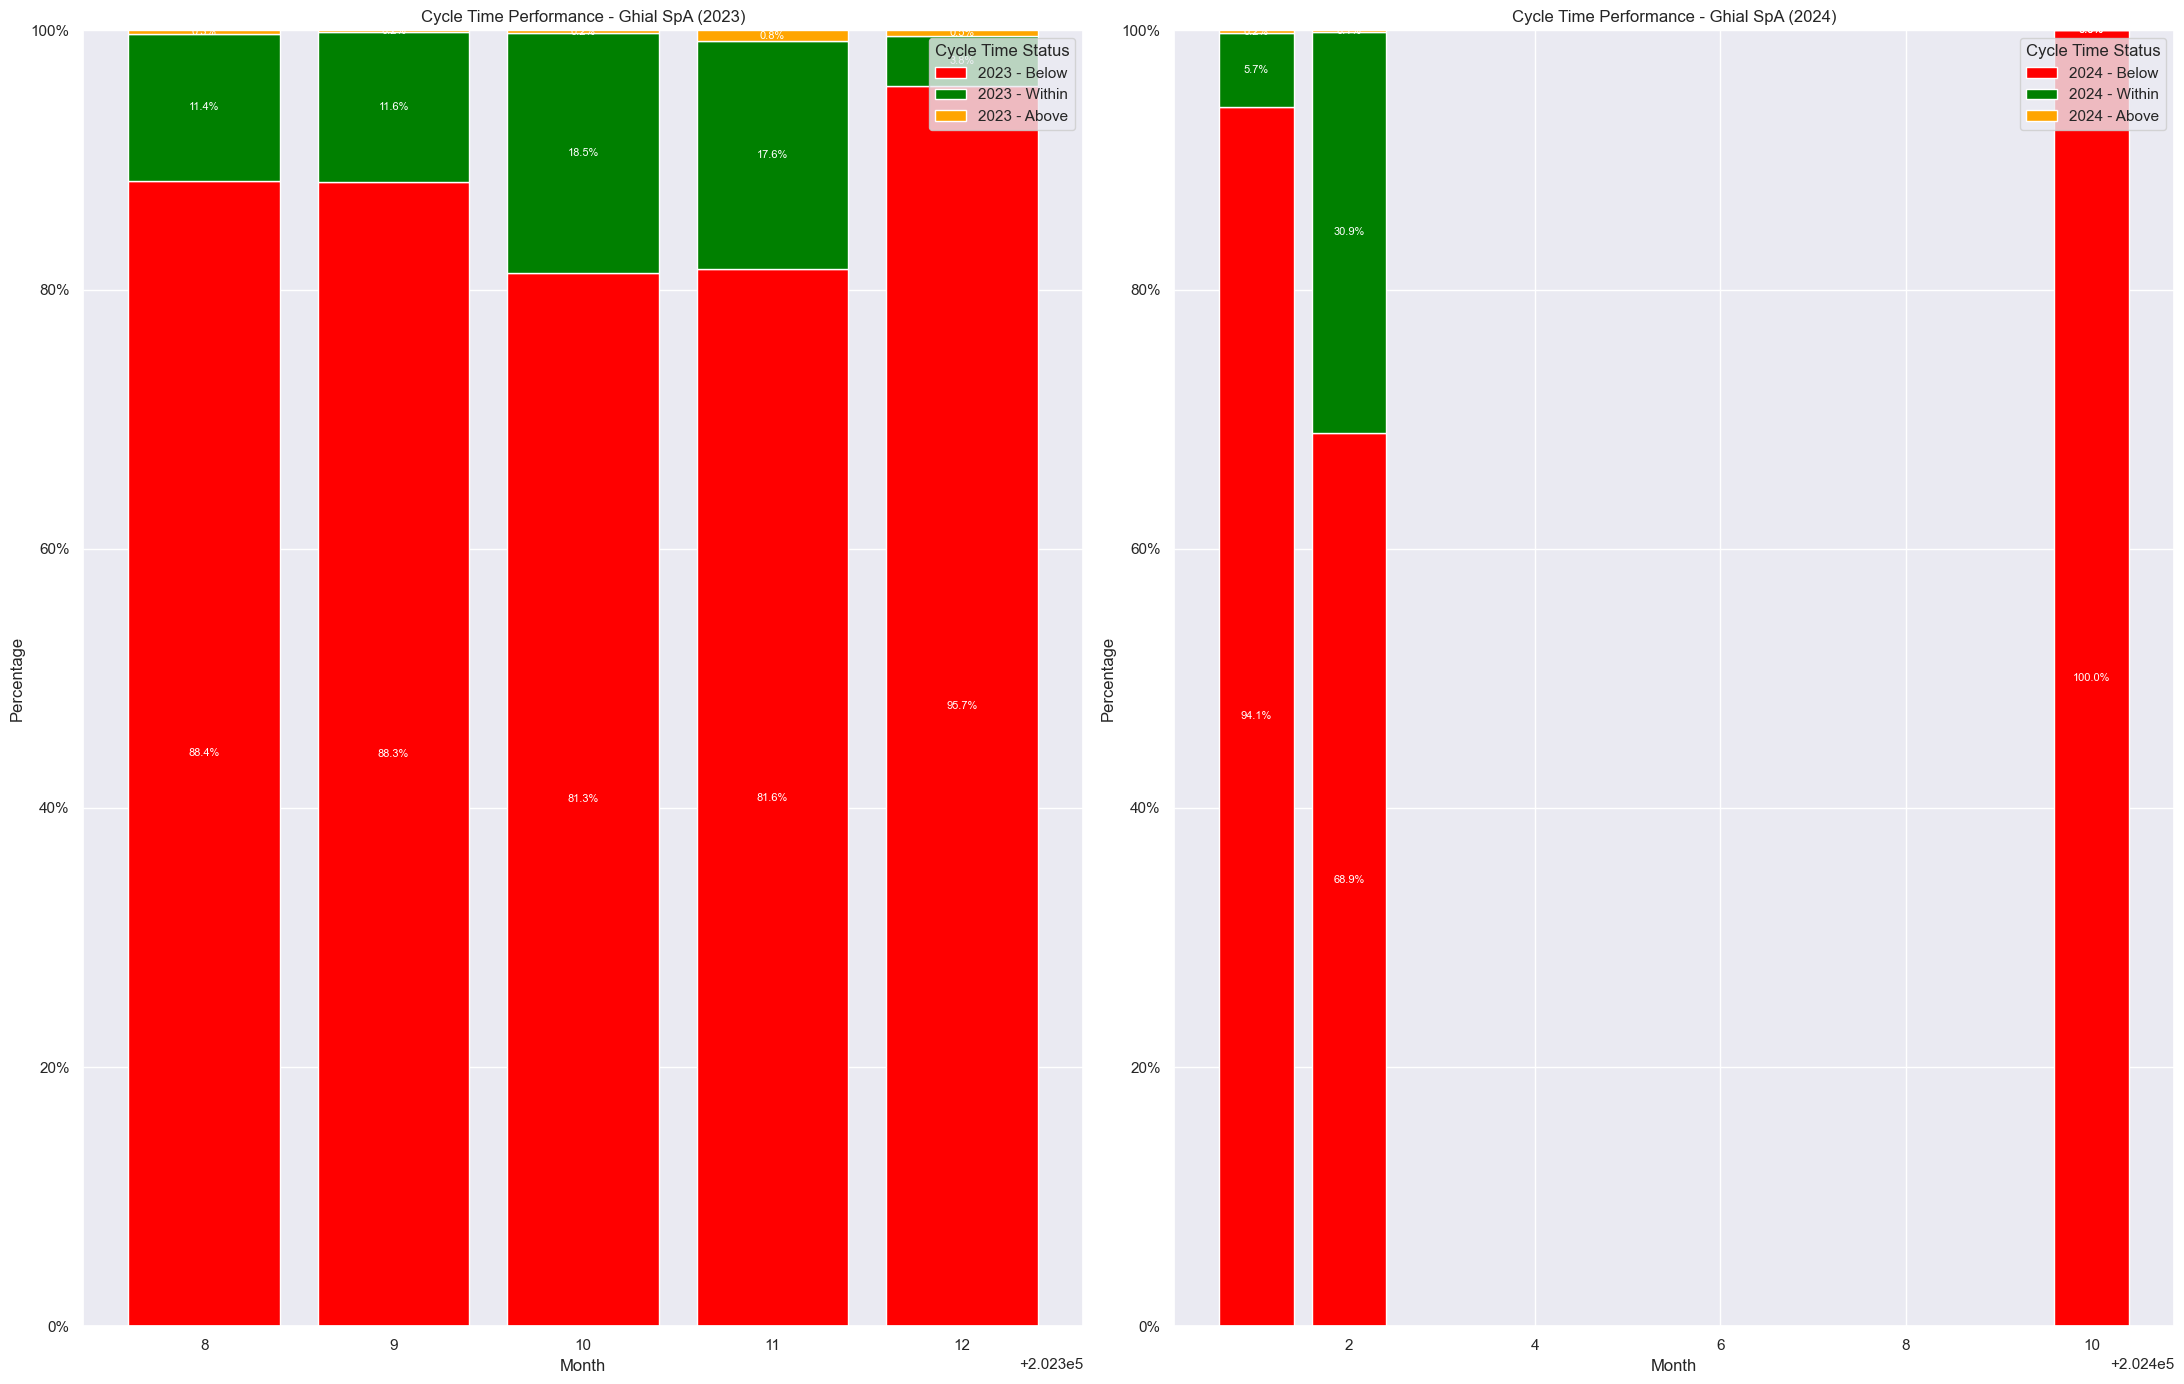

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np

# Set style for the plot
sns.set(style="darkgrid")

# Assuming cycle_time_performance already contains valid counts for the categories
# Calculate the total count for each year, month, and company
cycle_time_performance['TOTAL_COUNT'] = cycle_time_performance[['ABOVE_COUNT', 'WITHIN_COUNT', 'BELOW_COUNT']].sum(axis=1)

# Calculate the percentage for each category by dividing each count by the total count and multiplying by 100
cycle_time_performance['ABOVE_COUNT_percentage'] = (cycle_time_performance['ABOVE_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['WITHIN_COUNT_percentage'] = (cycle_time_performance['WITHIN_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100
cycle_time_performance['BELOW_COUNT_percentage'] = (cycle_time_performance['BELOW_COUNT'] / cycle_time_performance['TOTAL_COUNT']) * 100

# Filter the data starting from 2023-04-01 (from the MONTH column in YYYYMM format)
cycle_time_performance_filtered = cycle_time_performance[cycle_time_performance['MONTH'] >= 202304]

# Filter the data for "DAF Sheet Metal"
cycle_time_performance_daf = cycle_time_performance_filtered[cycle_time_performance_filtered['COMPANY_NAME'] == 'Ghial SpA']

# Group by MONTH and COMPANY_NAME to get monthly data
df_aggregated = cycle_time_performance_daf.groupby(['MONTH', 'COMPANY_NAME']).agg({
    'ABOVE_COUNT_percentage': 'mean',
    'WITHIN_COUNT_percentage': 'mean',
    'BELOW_COUNT_percentage': 'mean'
}).reset_index()

# Reshape the data to a long format (needed for hue usage)
df_long = pd.melt(df_aggregated, id_vars=['MONTH', 'COMPANY_NAME'], 
                  value_vars=['ABOVE_COUNT_percentage', 'WITHIN_COUNT_percentage', 'BELOW_COUNT_percentage'],
                  var_name='Cycle_Time_Status', value_name='Percentage')

# Create subplots for the DAF Sheet Metal data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14))  # Create two subplots side by side

# Only process DAF Sheet Metal data
company_data = df_long[df_long['COMPANY_NAME'] == 'Ghial SpA']

# Get the unique years and months
company_data['YEAR'] = company_data['MONTH'].astype(str).str[:4].astype(int)

# Filter data for 2023 and 2024
data_2023 = company_data[company_data['YEAR'] == 2023]
data_2024 = company_data[company_data['YEAR'] == 2024]

# Initialize bottom for stacking for 2023
bottom_2023 = [0] * len(data_2023['MONTH'].unique())

# Plot 2023 Data on the first subplot
months_2023 = sorted(data_2023['MONTH'].unique())
for cycle_status, color, label in zip(['BELOW_COUNT_percentage', 'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
                                      ['red', 'green', 'orange'],
                                      ['Below', 'Within', 'Above']):
    cycle_data = data_2023[data_2023['Cycle_Time_Status'] == cycle_status]
    bars = ax1.bar(cycle_data['MONTH'], cycle_data['Percentage'], color=color, label=f'2023 - {label}', bottom=bottom_2023)
    
    # Add percentage text on the bars and print out the values
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if np.isfinite(yval):  # Only plot text if yval is valid
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 + bottom_2023[i],
                     f'{yval:.1f}%', ha='center', va='center', color='white', fontsize=8)
            
            # Print the percentages as output
            print(f"2023 - Month: {cycle_data['MONTH'].iloc[i]}, Cycle Time Status: {label}, Percentage: {yval:.1f}%")
    
    bottom_2023 = [b + p for b, p in zip(bottom_2023, cycle_data['Percentage'])]

# Set the title and labels for the 2023 plot
ax1.set_title(f"Cycle Time Performance - Ghial SpA (2023)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Percentage")

# Manually set y-axis format to display percentages
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Set y-axis limit to ensure it always goes to 100%
ax1.set_ylim(0, 100)

# Add a legend for the 2023 plot
ax1.legend(title="Cycle Time Status", loc='upper right')

# Initialize bottom for stacking for 2024
bottom_2024 = [0] * len(data_2024['MONTH'].unique())

# Plot 2024 Data on the second subplot
months_2024 = sorted(data_2024['MONTH'].unique())
for cycle_status, color, label in zip(['BELOW_COUNT_percentage', 'WITHIN_COUNT_percentage', 'ABOVE_COUNT_percentage'],
                                      ['red', 'green', 'orange'],
                                      ['Below', 'Within', 'Above']):
    cycle_data = data_2024[data_2024['Cycle_Time_Status'] == cycle_status]
    bars = ax2.bar(cycle_data['MONTH'], cycle_data['Percentage'], color=color, label=f'2024 - {label}', bottom=bottom_2024)
    
    # Add percentage text on the bars and print out the values
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if np.isfinite(yval):  # Only plot text if yval is valid
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2 + bottom_2024[i],
                     f'{yval:.1f}%', ha='center', va='center', color='white', fontsize=8)
            
            # Print the percentages as output
            print(f"2024 - Month: {cycle_data['MONTH'].iloc[i]}, Cycle Time Status: {label}, Percentage: {yval:.1f}%")
    
    bottom_2024 = [b + p for b, p in zip(bottom_2024, cycle_data['Percentage'])]

# Set the title and labels for the 2024 plot
ax2.set_title(f"Cycle Time Performance - Ghial SpA (2024)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Percentage")

# Manually set y-axis format to display percentages
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Set y-axis limit to ensure it always goes to 100%
ax2.set_ylim(0, 100)

# Add a legend for the 2024 plot
ax2.legend(title="Cycle Time Status", loc='upper right')

plt.tight_layout()
plt.show()
